In [55]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
# Core scientific stack + raman_helpers module.
# os is needed for the incremental .npz save pattern used in every cell.
# All scipy imports are explicit so Pylance can resolve them correctly
# when the right interpreter is selected (pip install scipy if missing).

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.io as sio
from scipy.optimize import curve_fit
from scipy.special import erf, erfinv
import warnings

import RamanHelpers as rh

# ── Plot style ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "figure.dpi"      : 150,
    "axes.grid"       : True,
    "grid.alpha"      : 0.3,
    "axes.spines.top" : False,
    "axes.spines.right": False,
})

# ── Save helper ───────────────────────────────────────────────────────────────
SAVE_FILE = "fit_results.npz"

def save_results(**kwargs):
    """
    Incrementally update fit_results.npz with new key-value pairs.
    Loads existing data first so no previous results are lost.
    Call at the end of every fitting cell:
        save_results(si_cen_raw=cen_si, cal_offset=CAL_OFFSET, ...)
    """
    store = dict(np.load(SAVE_FILE, allow_pickle=True)) \
            if os.path.exists(SAVE_FILE) else {}
    store.update(kwargs)
    np.savez(SAVE_FILE, **store)
    keys = list(kwargs.keys())
    print(f"  ✓ Saved {len(keys)} variable(s) → {SAVE_FILE}")
    print(f"    {keys}")

print("Imports OK")
print(f"Save file  : {SAVE_FILE}")
print(f"rh version : {rh.__file__}")

Imports OK
Save file  : fit_results.npz
rh version : /Users/egeeroglu/Desktop/RIRO/RIRO-WS25-26-Raman/RamanData/RamanHelpers.py


Loaded   : 400 spectra
Points   : 8821  (40 – 4450 cm⁻¹)
Step     : 0.50 cm⁻¹

Best spectrum : index 134  (strongest 2D signal)
  2D peak max : 2090.0 counts


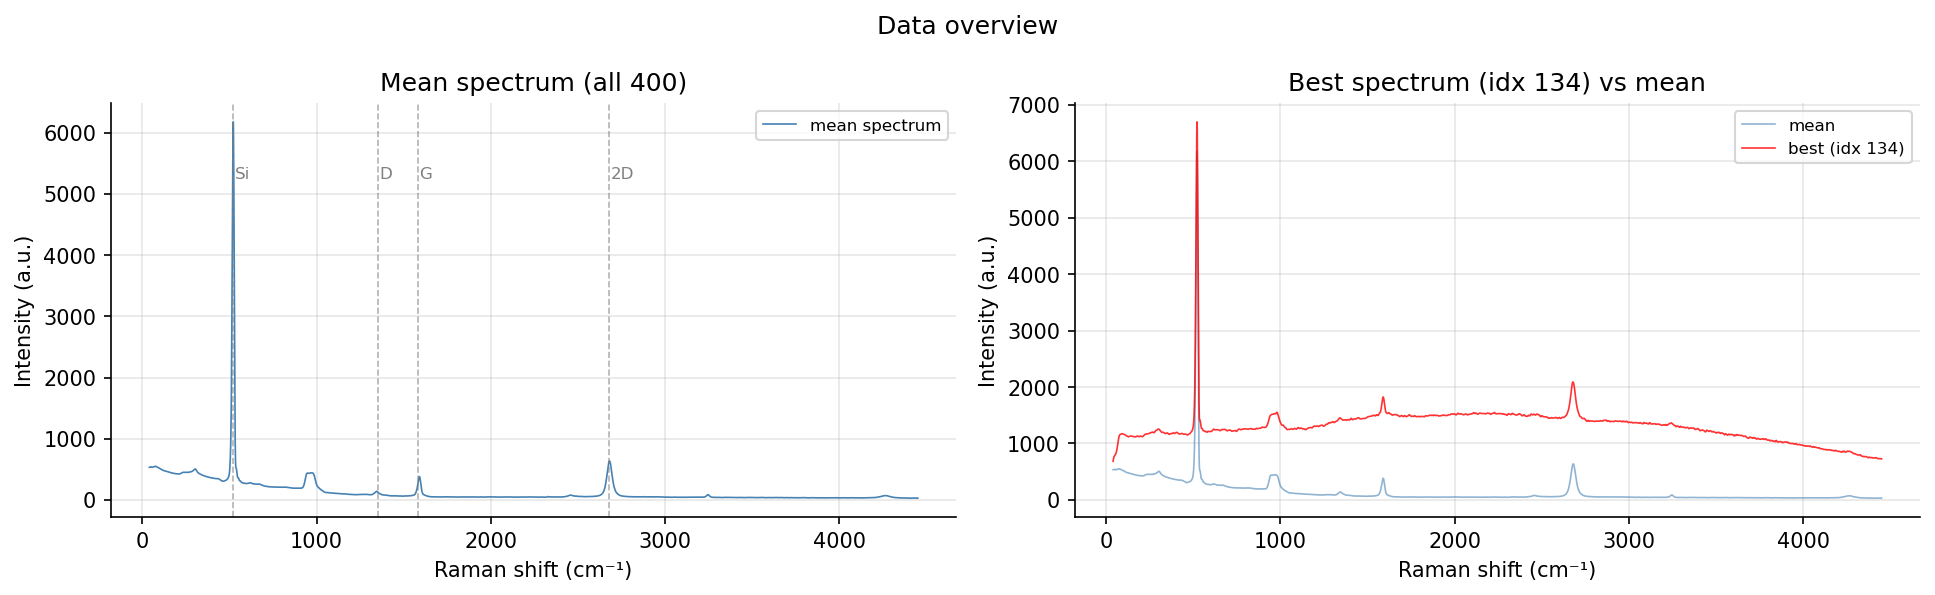

Saved: 01_data_overview.png
  ✓ Saved 1 variable(s) → fit_results.npz
    ['idx_best']


In [57]:
# ── Cell 2: Load data ─────────────────────────────────────────────────────────
# Loads the WITec .mat file and extracts the wavenumber axis and all spectra.
# Ra matrix layout: col 0 = wavenumber axis, cols 1-400 = spectra.
#
# Also selects the single best representative spectrum (highest 2D signal)
# which is used for all single-spectrum fitting cells.
# The mean spectrum is computed as a sanity check only — not used for fitting.

mat     = sio.loadmat("GrapheneMap20.0.mat")
Ra      = mat["Ra"]
wn      = Ra[:, 0]      # wavenumber axis  shape (8821,)
spectra = Ra[:, 1:]     # all 400 spectra  shape (8821, 400)

print(f"Loaded   : {spectra.shape[1]} spectra")
print(f"Points   : {len(wn)}  ({wn.min():.0f} – {wn.max():.0f} cm⁻¹)")
print(f"Step     : {wn[1]-wn[0]:.2f} cm⁻¹")

# ── Select best representative spectrum ───────────────────────────────────────
# Best = strongest 2D signal → cleanest monolayer region in the map.
# This spectrum is used for all single-spectrum fitting cells below.
# It is NOT the average — averaging mixes layer types and destroys spatial info.

wn_2D_mask = (wn >= 2600) & (wn <= 2800)
idx_best   = int(np.argmax(spectra[wn_2D_mask, :].max(axis=0)))
spec       = spectra[:, idx_best]

print(f"\nBest spectrum : index {idx_best}  (strongest 2D signal)")
print(f"  2D peak max : {spectra[wn_2D_mask, idx_best].max():.1f} counts")

# ── Mean spectrum — sanity check only ────────────────────────────────────────
mean_spec = spectra.mean(axis=1)

# ── Quick overview plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Data overview", fontsize=12)

# Left: mean spectrum with band labels
ax = axes[0]
ax.plot(wn, mean_spec, "steelblue", lw=0.8, label="mean spectrum")
for pos, label in [(521,"Si"), (1350,"D"), (1580,"G"), (2680,"2D")]:
    ax.axvline(pos, color="grey", lw=0.8, ls="--", alpha=0.6)
    ax.text(pos+10, mean_spec.max()*0.85, label, fontsize=8, color="grey")
ax.set_xlabel("Raman shift (cm⁻¹)")
ax.set_ylabel("Intensity (a.u.)")
ax.set_title("Mean spectrum (all 400)")
ax.legend(fontsize=8)

# Right: best spectrum vs mean
ax = axes[1]
ax.plot(wn, mean_spec,          "steelblue", lw=0.8, alpha=0.6, label="mean")
ax.plot(wn, spec,               "red",       lw=0.8, alpha=0.8,
        label=f"best (idx {idx_best})")
ax.set_xlabel("Raman shift (cm⁻¹)")
ax.set_ylabel("Intensity (a.u.)")
ax.set_title(f"Best spectrum (idx {idx_best}) vs mean")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("01_data_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 01_data_overview.png")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    idx_best  = idx_best,
)

### Load calibration data from npzConverter.ipynb: ###

In [58]:
# ── Cell 3: Load calibration from calibration_results.npz ────────────────────
# Instead of refitting the Si peak here, we pull the already-computed
# calibration offset from the dedicated calibration notebook.
# This ensures the main analysis and calibration notebooks are consistent
# — one source of truth for CAL_OFFSET.
#
# Requires: calibration_results.npz exists in the same directory.
# Run the calibration notebook first if the file is missing.

CAL_FILE = "calibration_results.npz"

if not os.path.exists(CAL_FILE):
    raise FileNotFoundError(
        f"{CAL_FILE} not found.\n"
        f"Run the calibration notebook first to generate it."
    )

cal = np.load(CAL_FILE, allow_pickle=True)

# ── Pull calibration values ───────────────────────────────────────────────────
CAL_OFFSET   = float(cal["cal_offset"])
si_cen_raw   = float(cal["si_cen_raw_GrapheneMap20"])
si_fwhm      = float(cal["si_fwhm_GrapheneMap20"])
si_cen_err   = float(cal["si_cen_err_GrapheneMap20"])
si_fwhm_err  = float(cal["si_fwhm_err_GrapheneMap20"])

# ── Status ────────────────────────────────────────────────────────────────────
status = ("✓ Good         (< 1 cm⁻¹)"  if abs(CAL_OFFSET) < 1.0 else
          "~ Acceptable   (1–2 cm⁻¹)"  if abs(CAL_OFFSET) < 2.0 else
          "✗ Recalibrate  (> 2 cm⁻¹)")

print(f"── Calibration loaded from {CAL_FILE} ───────────────────────────────")
print(f"  si_cen_raw  : {si_cen_raw:.3f} ± {si_cen_err:.3f} cm⁻¹")
print(f"  si_fwhm     : {si_fwhm:.3f} ± {si_fwhm_err:.3f} cm⁻¹")
print(f"  CAL_OFFSET  : {CAL_OFFSET:+.3f} cm⁻¹  →  {status}")
print(f"\n  All subsequent peak centres corrected by {CAL_OFFSET:+.3f} cm⁻¹")
print(f"  FWHMs and intensity ratios are NOT affected.")

# ── Save to main fit_results.npz ──────────────────────────────────────────────
save_results(
    cal_offset  = CAL_OFFSET,
    si_cen_raw  = si_cen_raw,
    si_fwhm     = si_fwhm,
    si_cen_err  = si_cen_err,
    si_fwhm_err = si_fwhm_err,
)

── Calibration loaded from calibration_results.npz ───────────────────────────────
  si_cen_raw  : 521.081 ± 0.091 cm⁻¹
  si_fwhm     : 11.008 ± 0.258 cm⁻¹
  CAL_OFFSET  : +1.081 cm⁻¹  →  ~ Acceptable   (1–2 cm⁻¹)

  All subsequent peak centres corrected by +1.081 cm⁻¹
  FWHMs and intensity ratios are NOT affected.
  ✓ Saved 5 variable(s) → fit_results.npz
    ['cal_offset', 'si_cen_raw', 'si_fwhm', 'si_cen_err', 'si_fwhm_err']


### Fitting the characteristic peaks: ###

── Model A: G only ──────────────────────────────────────────────
  g_amp        : 349.51 ± 4.03
  g_cen_raw    : 1589.550 ± 0.119 cm⁻¹
  g_cen_corr   : 1588.469 cm⁻¹
  g_fwhm       : 20.704 ± 0.338 cm⁻¹
  RMS residual : 16.1829

── Model B: G + D' ──────────────────────────────────────────────
  g_amp        : 354.24 ± 3.67
  g_cen_raw    : 1589.403 ± 0.104 cm⁻¹
  g_cen_corr   : 1588.322 cm⁻¹
  g_fwhm       : 19.377 ± 0.328 cm⁻¹
  dp_amp       : 32.33 ± 3.73
  dp_cen_raw   : 1625.812 ± 1.116 cm⁻¹
  dp_cen_corr  : 1624.731 cm⁻¹
  dp_fwhm      : 18.746 ± 3.539 cm⁻¹
  RMS residual : 14.1296

── Model comparison ─────────────────────────────────────────────────
  RMS Model A (G only) : 16.18289
  RMS Model B (G + D') : 14.12960
  RMS improvement      : 12.7%
  Decision : ✓ Model B chosen  (>10% improvement — D' is real)

── Final: G + D' (Model B) ──────────────────────────────────────
  g_cen_corr   : 1588.322 cm⁻¹
  g_fwhm       : 19.377 cm⁻¹
  dp_cen_corr  : 1624.731 cm⁻¹
  dp_fwhm    

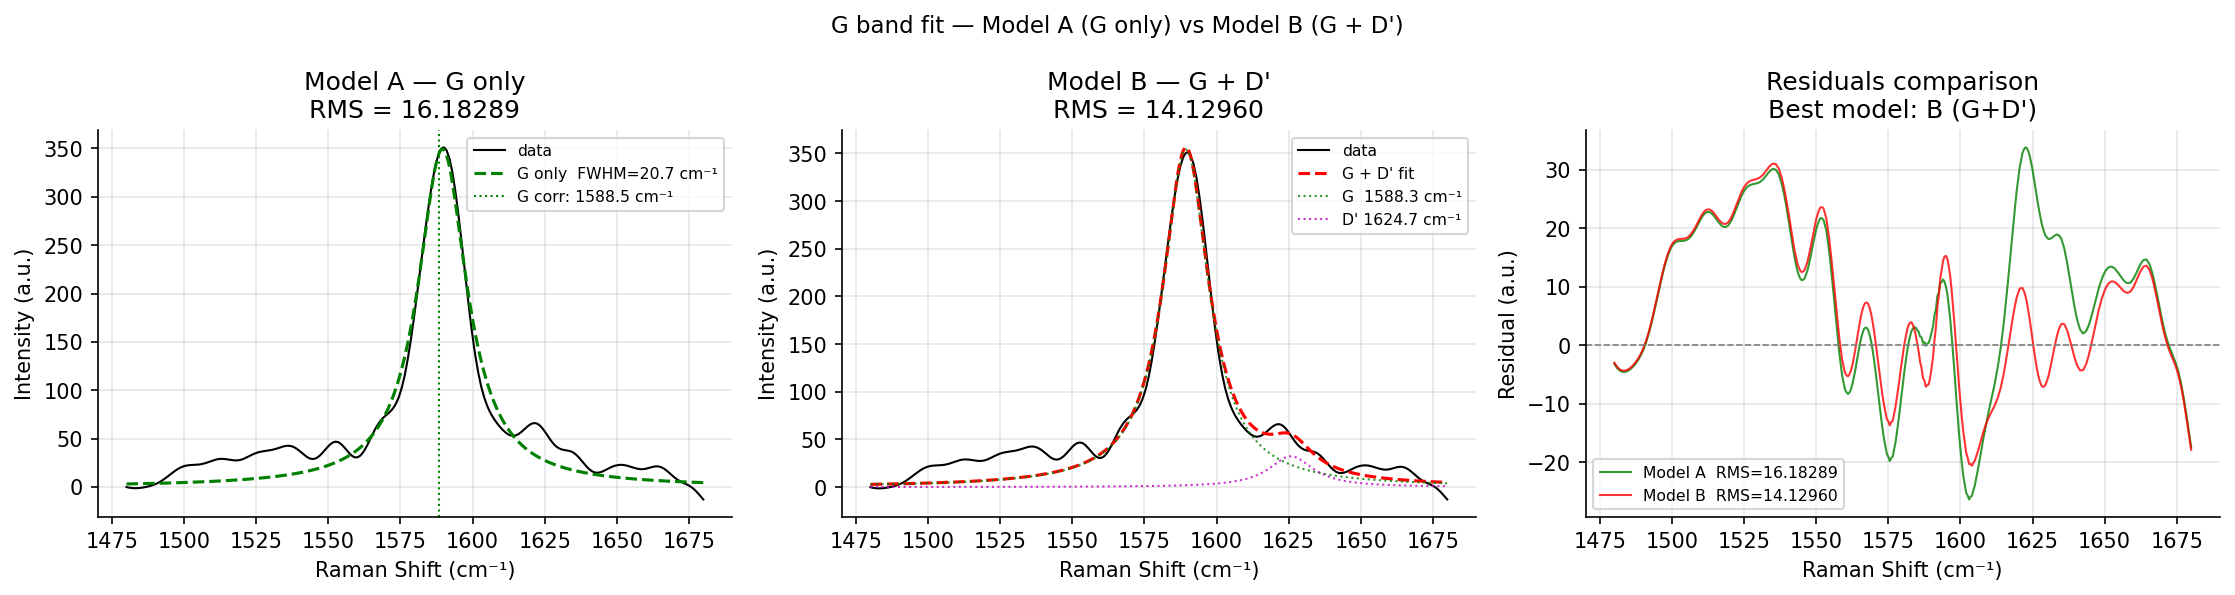

Saved: 03_G_fit.png
  ✓ Saved 22 variable(s) → fit_results.npz
    ['g_amp', 'g_amp_err', 'g_cen_raw', 'g_cen_err', 'g_cen_corr', 'g_fwhm', 'g_fwhm_err', 'g_area', 'g_model', 'g_rms_modelA', 'g_rms_modelB', 'dp_amp', 'dp_amp_err', 'dp_cen_raw', 'dp_cen_err', 'dp_cen_corr', 'dp_fwhm', 'dp_fwhm_err', 'dp_area', 'dp_ok', 'g_rms_improvement', 'd_rms_improvement']


In [61]:
# ── Cell 4: G band + D' shoulder fit (~1580 + ~1625 cm⁻¹) ───────────────────
# The G band is the primary Raman signature of sp² carbon.
# A D' shoulder at ~1620–1625 cm⁻¹ may be present alongside the G band —
# it requires a defect (intra-valley scattering) just like the D band.
#
# Strategy: fit G alone first, then G+D' simultaneously.
# Compare residuals — if G+D' gives significantly lower RMS residual,
# the D' shoulder is real and resolvable.
#
# I(D)/I(D') ratio fingerprints defect type (amplitude ratio):
#   > 10  → sp³ / adatom defects
#   5–10  → vacancy-type defects
#   < 5   → grain boundaries / edges
#
# Naming convention:
#   g_amp, g_cen_raw, g_cen_corr, g_fwhm, g_area   → G band (best model)
#   dp_amp, dp_cen_raw, dp_cen_corr, dp_fwhm        → D' band
#   g_model                                          → "single" or "double"

# ── Safety check ─────────────────────────────────────────────────────────────
if "CAL_OFFSET" not in dir():
    raise RuntimeError("CAL_OFFSET not defined — run calibration cell first.")

# ── Crop and baseline ─────────────────────────────────────────────────────────
# Wide enough window to capture both G and D'
wn_G, sp_G = rh.crop(wn, spec, 1480, 1680)
bl_G       = rh.linear_baseline(wn_G, sp_G, 1490, 1670)
sp_G_bl    = sp_G - bl_G

# ── Model A: single Lorentzian (G only) ───────────────────────────────────────
p0_A     = [sp_G_bl.max(), 1580, 15]
bounds_A = ([0, 1550, 5], [np.inf, 1620, 50])

try:
    popt_A, pcov_A = curve_fit(rh.lorentzian, wn_G, sp_G_bl,
                               p0=p0_A, bounds=bounds_A, maxfev=5000)
    perr_A                      = np.sqrt(np.diag(pcov_A))
    amp_A,     cen_A,     fwhm_A     = popt_A
    amp_A_err, cen_A_err, fwhm_A_err = perr_A
    fit_A      = rh.lorentzian(wn_G, *popt_A)
    resid_A    = sp_G_bl - fit_A
    rms_A      = np.sqrt(np.mean(resid_A**2))
    fit_A_ok   = True
    print(f"── Model A: G only ──────────────────────────────────────────────")
    print(f"  g_amp        : {amp_A:.2f} ± {amp_A_err:.2f}")
    print(f"  g_cen_raw    : {cen_A:.3f} ± {cen_A_err:.3f} cm⁻¹")
    print(f"  g_cen_corr   : {cen_A - CAL_OFFSET:.3f} cm⁻¹")
    print(f"  g_fwhm       : {fwhm_A:.3f} ± {fwhm_A_err:.3f} cm⁻¹")
    print(f"  RMS residual : {rms_A:.4f}")
except RuntimeError:
    fit_A_ok = False
    raise RuntimeError("G band single fit failed — check spectrum.")

# ── Model B: two Lorentzians (G + D') ────────────────────────────────────────
def two_lorentzians(x, amp1, cen1, fwhm1, amp2, cen2, fwhm2):
    return rh.lorentzian(x, amp1, cen1, fwhm1) + \
           rh.lorentzian(x, amp2, cen2, fwhm2)

p0_B     = [amp_A, cen_A, fwhm_A,   amp_A * 0.1, 1625, 15]
bounds_B = ([0, 1550, 3, 0, 1610, 3],
            [np.inf, 1620, 50, np.inf, 1650, 40])

try:
    popt_B, pcov_B = curve_fit(two_lorentzians, wn_G, sp_G_bl,
                               p0=p0_B, bounds=bounds_B, maxfev=8000)
    perr_B = np.sqrt(np.diag(pcov_B))
    amp_G_B,  cen_G_B,  fwhm_G_B  = popt_B[:3]
    amp_Dp_B, cen_Dp_B, fwhm_Dp_B = popt_B[3:]
    amp_G_B_err,  cen_G_B_err,  fwhm_G_B_err  = perr_B[:3]
    amp_Dp_B_err, cen_Dp_B_err, fwhm_Dp_B_err = perr_B[3:]
    fit_B      = two_lorentzians(wn_G, *popt_B)
    resid_B    = sp_G_bl - fit_B
    rms_B      = np.sqrt(np.mean(resid_B**2))
    fit_B_ok   = True
    print(f"\n── Model B: G + D' ──────────────────────────────────────────────")
    print(f"  g_amp        : {amp_G_B:.2f} ± {amp_G_B_err:.2f}")
    print(f"  g_cen_raw    : {cen_G_B:.3f} ± {cen_G_B_err:.3f} cm⁻¹")
    print(f"  g_cen_corr   : {cen_G_B - CAL_OFFSET:.3f} cm⁻¹")
    print(f"  g_fwhm       : {fwhm_G_B:.3f} ± {fwhm_G_B_err:.3f} cm⁻¹")
    print(f"  dp_amp       : {amp_Dp_B:.2f} ± {amp_Dp_B_err:.2f}")
    print(f"  dp_cen_raw   : {cen_Dp_B:.3f} ± {cen_Dp_B_err:.3f} cm⁻¹")
    print(f"  dp_cen_corr  : {cen_Dp_B - CAL_OFFSET:.3f} cm⁻¹")
    print(f"  dp_fwhm      : {fwhm_Dp_B:.3f} ± {fwhm_Dp_B_err:.3f} cm⁻¹")
    print(f"  RMS residual : {rms_B:.4f}")
except RuntimeError:
    fit_B_ok = False
    print("  G + D' fit did not converge — D' shoulder not resolvable")

# ── Model comparison ──────────────────────────────────────────────────────────
# Improvement threshold: Model B must reduce RMS by > 20% to justify
# the extra two free parameters (D' amp and centre).
# This is a practical version of an F-test / AIC model selection.

IMPROVEMENT_THRESHOLD = 0.10   # 20%

print(f"\n── Model comparison ─────────────────────────────────────────────────")
print(f"  RMS Model A (G only) : {rms_A:.5f}")

if fit_B_ok:
    improvement = (rms_A - rms_B) / rms_A
    print(f"  RMS Model B (G + D') : {rms_B:.5f}")
    print(f"  RMS improvement      : {100*improvement:.1f}%")

    if improvement > IMPROVEMENT_THRESHOLD:
        best_model = "double"
        print(f"  Decision : ✓ Model B chosen  "
              f"(>{100*IMPROVEMENT_THRESHOLD:.0f}% improvement — D' is real)")
    else:
        best_model = "single"
        print(f"  Decision : Model A chosen  "
              f"(<{100*IMPROVEMENT_THRESHOLD:.0f}% improvement — D' not significant)")
else:
    best_model = "single"
    print(f"  Decision : Model A chosen  (Model B did not converge)")

# ── Assign final G band parameters from best model ───────────────────────────
if best_model == "double":
    amp_G     = amp_G_B;    amp_G_err   = amp_G_B_err
    cen_G     = cen_G_B;    cen_G_err   = cen_G_B_err
    fwhm_G    = fwhm_G_B;   fwhm_G_err  = fwhm_G_B_err
    amp_Dp    = amp_Dp_B;   amp_Dp_err  = amp_Dp_B_err
    cen_Dp    = cen_Dp_B;   cen_Dp_err  = cen_Dp_B_err
    fwhm_Dp   = fwhm_Dp_B;  fwhm_Dp_err = fwhm_Dp_B_err
    dp_ok     = True
else:
    amp_G     = amp_A;      amp_G_err   = amp_A_err
    cen_G     = cen_A;      cen_G_err   = cen_A_err
    fwhm_G    = fwhm_A;     fwhm_G_err  = fwhm_A_err
    amp_Dp    = np.nan;     amp_Dp_err  = np.nan
    cen_Dp    = np.nan;     cen_Dp_err  = np.nan
    fwhm_Dp   = np.nan;     fwhm_Dp_err = np.nan
    dp_ok     = False

cen_G_corr  = cen_G  - CAL_OFFSET
area_G      = amp_G  * fwhm_G  * np.pi / 2

if dp_ok:
    cen_Dp_corr = cen_Dp - CAL_OFFSET
    area_Dp     = amp_Dp * fwhm_Dp * np.pi / 2
    ratio_D_Dp_amp  = np.nan   # filled in after D band cell
    print(f"\n── Final: G + D' (Model B) ──────────────────────────────────────")
    print(f"  g_cen_corr   : {cen_G_corr:.3f} cm⁻¹")
    print(f"  g_fwhm       : {fwhm_G:.3f} cm⁻¹")
    print(f"  dp_cen_corr  : {cen_Dp_corr:.3f} cm⁻¹")
    print(f"  dp_fwhm      : {fwhm_Dp:.3f} cm⁻¹")
else:
    cen_Dp_corr = np.nan
    area_Dp     = np.nan
    print(f"\n── Final: G only (Model A) ──────────────────────────────────────")
    print(f"  g_cen_corr   : {cen_G_corr:.3f} cm⁻¹")
    print(f"  g_fwhm       : {fwhm_G:.3f} cm⁻¹")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("G band fit — Model A (G only) vs Model B (G + D')", fontsize=11)

# Left: Model A
ax = axes[0]
ax.plot(wn_G, sp_G_bl, "k", lw=1, label="data")
ax.plot(wn_G, fit_A, "g--", lw=1.5,
        label=f"G only  FWHM={fwhm_A:.1f} cm⁻¹")
ax.axvline(cen_A - CAL_OFFSET, color="green", lw=1, ls=":",
           label=f"G corr: {cen_A - CAL_OFFSET:.1f} cm⁻¹")
ax.set_title(f"Model A — G only\nRMS = {rms_A:.5f}")
ax.set_xlabel("Raman Shift (cm⁻¹)")
ax.set_ylabel("Intensity (a.u.)")
ax.legend(fontsize=7.5)

# Middle: Model B
ax = axes[1]
ax.plot(wn_G, sp_G_bl, "k", lw=1, label="data")
if fit_B_ok:
    ax.plot(wn_G, fit_B, "r--", lw=1.5, label="G + D' fit")
    ax.plot(wn_G, rh.lorentzian(wn_G, amp_G_B, cen_G_B, fwhm_G_B),
            "g:", lw=1, alpha=0.8,
            label=f"G  {cen_G_B - CAL_OFFSET:.1f} cm⁻¹")
    ax.plot(wn_G, rh.lorentzian(wn_G, amp_Dp_B, cen_Dp_B, fwhm_Dp_B),
            "m:", lw=1, alpha=0.8,
            label=f"D' {cen_Dp_B - CAL_OFFSET:.1f} cm⁻¹")
    ax.set_title(f"Model B — G + D'\nRMS = {rms_B:.5f}")
else:
    ax.set_title("Model B — did not converge")
ax.set_xlabel("Raman Shift (cm⁻¹)")
ax.set_ylabel("Intensity (a.u.)")
ax.legend(fontsize=7.5)

# Right: residuals comparison
ax = axes[2]
ax.plot(wn_G, resid_A, "g-", lw=1, alpha=0.8,
        label=f"Model A  RMS={rms_A:.5f}")
if fit_B_ok:
    ax.plot(wn_G, resid_B, "r-", lw=1, alpha=0.8,
            label=f"Model B  RMS={rms_B:.5f}")
ax.axhline(0, color="grey", lw=0.8, ls="--")
winner = "B (G+D')" if best_model == "double" else "A (G only)"
ax.set_title(f"Residuals comparison\nBest model: {winner}")
ax.set_xlabel("Raman Shift (cm⁻¹)")
ax.set_ylabel("Residual (a.u.)")
ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig("03_G_fit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 03_G_fit.png")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    # G band — best model values
    g_amp        = amp_G,
    g_amp_err    = amp_G_err,
    g_cen_raw    = cen_G,
    g_cen_err    = cen_G_err,
    g_cen_corr   = cen_G_corr,
    g_fwhm       = fwhm_G,
    g_fwhm_err   = fwhm_G_err,
    g_area       = area_G,
    g_model      = best_model,   # "single" or "double"
    # Model A vs B comparison
    g_rms_modelA = rms_A,
    g_rms_modelB = rms_B if fit_B_ok else np.nan,
    # D' band — only meaningful if best_model == "double"
    dp_amp       = amp_Dp,
    dp_amp_err   = amp_Dp_err,
    dp_cen_raw   = cen_Dp,
    dp_cen_err   = cen_Dp_err,
    dp_cen_corr  = cen_Dp_corr,
    dp_fwhm      = fwhm_Dp,
    dp_fwhm_err  = fwhm_Dp_err,
    dp_area      = area_Dp,
    dp_ok        = dp_ok,
    # Add to save_results() call in both cells
    g_rms_improvement  = improvement if fit_B_ok else np.nan,   # G band cell
    d_rms_improvement = improvement if fit_B_ok else np.nan,   # 2D band cell
)

Model B delivers an RMS improvement of 12.7% and thus the D' shoulder is to be considered. 

2D Fit with different models: 

── Model A: single Lorentzian ───────────────────────────────────
  td_amp       : 697.99 ± 4.40
  td_cen_raw   : 2679.584 ± 0.094 cm⁻¹
  td_cen_corr  : 2678.503 cm⁻¹
  td_fwhm      : 29.722 ± 0.266 cm⁻¹
  RMS residual : 21.1819

── Model B: two Lorentzians ─────────────────────────────────────
  Component 1  : amp=411.1  cen=2672.18 cm⁻¹  fwhm=22.9 cm⁻¹
  Component 2  : amp=418.0  cen=2684.81 cm⁻¹  fwhm=24.7 cm⁻¹
  Split        : 12.6 cm⁻¹  →  bilayer-like (higher component ~+13 cm⁻¹)
  RMS residual : 13.9063

── Model comparison ─────────────────────────────────────────────────
  RMS Model A (single)  : 21.18188
  RMS Model B (double)  : 13.90630
  RMS improvement       : 34.3%
  Both components OK    : True
  Decision : ✓ Model B chosen — two components significant

── Final 2D band parameters ─────────────────────────────────────────
  td_amp          : 417.96 ± 23.92
  td_cen_raw      : 2685.894 ± 0.444 cm⁻¹
  td_cen_corr     : 2684.813 cm⁻¹  (ref: 2680.0 cm⁻¹)
  Shift from ref  :

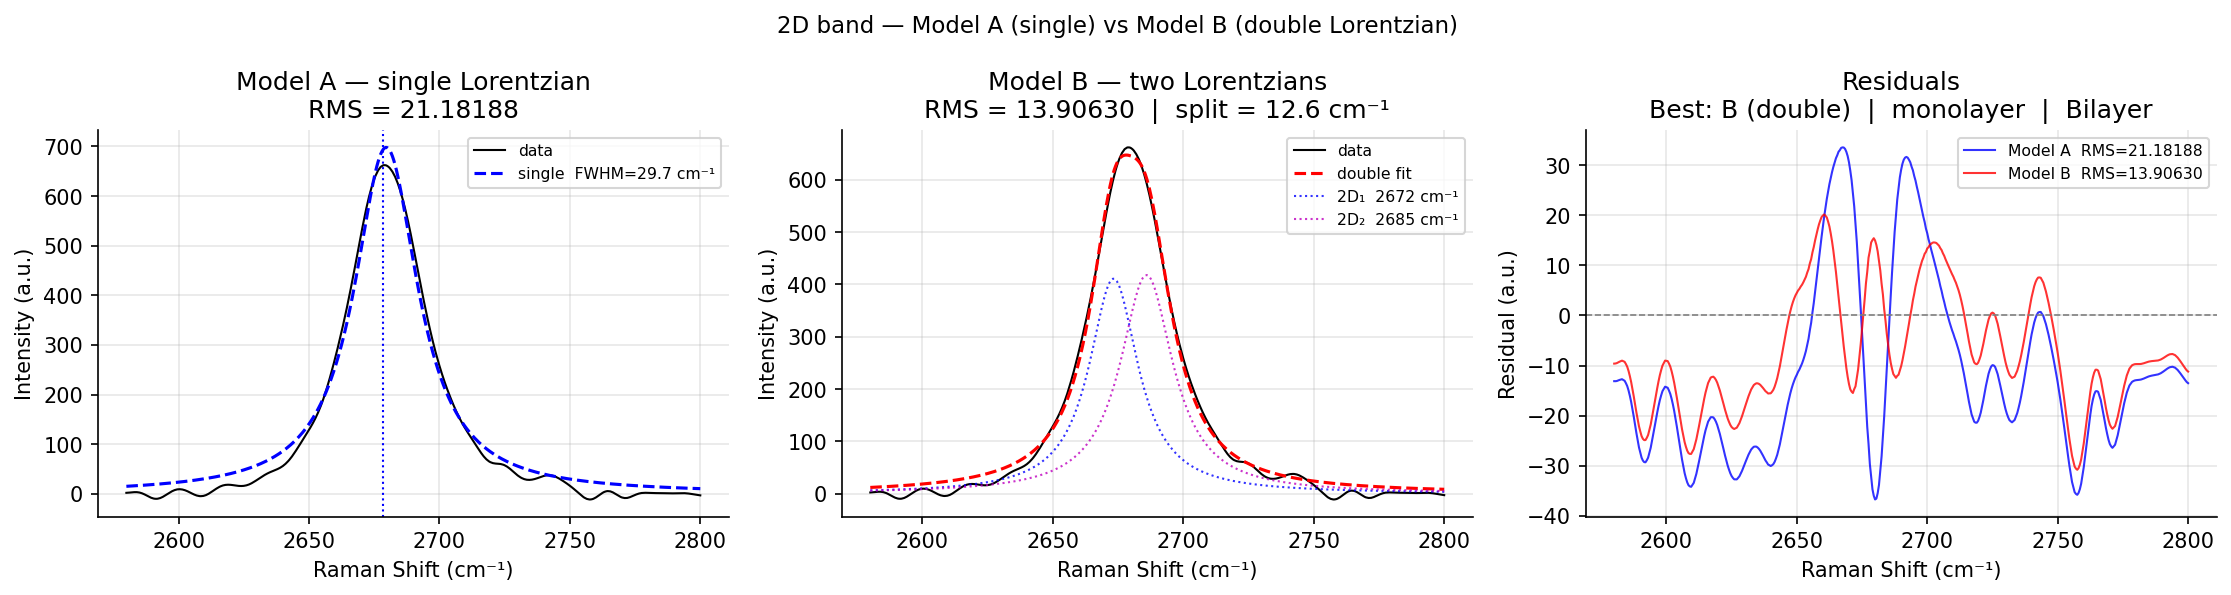

Saved: 04_2D_fit.png
  ✓ Saved 26 variable(s) → fit_results.npz
    ['td_amp', 'td_amp_err', 'td_cen_raw', 'td_cen_err', 'td_cen_corr', 'td_fwhm', 'td_fwhm_err', 'td_area', 'td_model', 'td_rms_modelA', 'td_rms_modelB', 'td_amp_B1', 'td_cen_B1_corr', 'td_fwhm_B1', 'td_amp_B2', 'td_cen_B2_corr', 'td_fwhm_B2', 'td_split', 'td_split_type', 'td_fwhm_verdict', 'td_layer_code', 'td_layer_name', 'ratio_2dg_amp', 'ratio_2dg_area', 'g_rms_improvement', 'td_rms_improvement']


In [63]:
# ── Cell 5: 2D band fit (~2680 cm⁻¹) ─────────────────────────────────────────
# 2D band is the second-order overtone of the D band (no defect required).
# Its lineshape is the most reliable layer number indicator.
#
# Models considered:
#   Model A — single Lorentzian
#             → monolayer graphene (FWHM 25–35 cm⁻¹)
#
#   Model B — two Lorentzians
#             → bilayer: components at ~2690 and ~2705 cm⁻¹
#             → OR strained monolayer: 2D⁺ and 2D⁻ split by ~15–20 cm⁻¹
#               (strain lifts the K-point degeneracy)
#
# Decision: Model B chosen only if RMS improves by > 20% AND
#           both components have physically reasonable parameters.
#
# 2D position is dispersive: ~106 cm⁻¹/eV with laser energy.
# For 532 nm (2.33 eV): theoretical ~2667 cm⁻¹, typical CVD ~2678 cm⁻¹.
#
# Naming convention:
#   td_amp, td_cen_raw, td_cen_corr, td_fwhm, td_area  → 2D band (best model)
#   td_amp_B1/B2, td_cen_B1/B2, td_fwhm_B1/B2          → two-component fit
#   td_model                                             → "single" or "double"

REF_2D = 2680.0   # cm⁻¹, nominal reference
IMPROVEMENT_THRESHOLD = 0.20

# ── Safety checks ─────────────────────────────────────────────────────────────
if "CAL_OFFSET" not in dir():
    raise RuntimeError("CAL_OFFSET not defined — run calibration cell first.")
if "amp_G" not in dir():
    raise RuntimeError("amp_G not defined — run G band cell first.")

# ── Crop and baseline ─────────────────────────────────────────────────────────
wn_2D, sp_2D = rh.crop(wn, spec, 2580, 2800)
bl_2D        = rh.linear_baseline(wn_2D, sp_2D, 2590, 2790)
sp_2D_bl     = sp_2D - bl_2D

# ── Model A: single Lorentzian ────────────────────────────────────────────────
p0_A     = [sp_2D_bl.max(), 2680, 30]
bounds_A = ([0, 2620, 10], [np.inf, 2760, 100])

try:
    popt_A, pcov_A = curve_fit(rh.lorentzian, wn_2D, sp_2D_bl,
                               p0=p0_A, bounds=bounds_A, maxfev=5000)
    perr_A                        = np.sqrt(np.diag(pcov_A))
    amp_A,     cen_A,     fwhm_A     = popt_A
    amp_A_err, cen_A_err, fwhm_A_err = perr_A
    fit_A      = rh.lorentzian(wn_2D, *popt_A)
    resid_A    = sp_2D_bl - fit_A
    rms_A      = np.sqrt(np.mean(resid_A**2))
    fit_A_ok   = True
    print(f"── Model A: single Lorentzian ───────────────────────────────────")
    print(f"  td_amp       : {amp_A:.2f} ± {amp_A_err:.2f}")
    print(f"  td_cen_raw   : {cen_A:.3f} ± {cen_A_err:.3f} cm⁻¹")
    print(f"  td_cen_corr  : {cen_A - CAL_OFFSET:.3f} cm⁻¹")
    print(f"  td_fwhm      : {fwhm_A:.3f} ± {fwhm_A_err:.3f} cm⁻¹")
    print(f"  RMS residual : {rms_A:.4f}")
except RuntimeError:
    fit_A_ok = False
    raise RuntimeError("2D single Lorentzian fit failed — check spectrum.")

# ── Model B: two Lorentzians ──────────────────────────────────────────────────
# Component 1: main 2D peak (~2680 cm⁻¹)
# Component 2: either
#   bilayer shoulder  → ~2705 cm⁻¹  (split ~+20 cm⁻¹)
#   strain component  → ~2665 cm⁻¹  (split ~−15 cm⁻¹)
# We let the fitter decide — bounds are wide enough to find either

def two_lorentzians(x, amp1, cen1, fwhm1, amp2, cen2, fwhm2):
    return rh.lorentzian(x, amp1, cen1, fwhm1) + \
           rh.lorentzian(x, amp2, cen2, fwhm2)

# Seed: main component from Model A, secondary ~15 cm⁻¹ higher
p0_B     = [amp_A,       cen_A,        fwhm_A,
            amp_A * 0.4, cen_A + 15.0, fwhm_A]
bounds_B = ([0, 2620, 5,  0, 2640, 5],
            [np.inf, 2730, 80, np.inf, 2760, 80])

try:
    popt_B, pcov_B = curve_fit(two_lorentzians, wn_2D, sp_2D_bl,
                               p0=p0_B, bounds=bounds_B, maxfev=8000)
    perr_B = np.sqrt(np.diag(pcov_B))
    amp_B1,     cen_B1,     fwhm_B1     = popt_B[:3]
    amp_B2,     cen_B2,     fwhm_B2     = popt_B[3:]
    amp_B1_err, cen_B1_err, fwhm_B1_err = perr_B[:3]
    amp_B2_err, cen_B2_err, fwhm_B2_err = perr_B[3:]
    fit_B      = two_lorentzians(wn_2D, *popt_B)
    resid_B    = sp_2D_bl - fit_B
    rms_B      = np.sqrt(np.mean(resid_B**2))
    fit_B_ok   = True

    # Interpret the splitting
    split    = abs(cen_B2 - cen_B1)
    if split < 5:
        split_type = "not significant (<5 cm⁻¹ split)"
    elif cen_B2 > cen_B1 and split > 10:
        split_type = "bilayer-like (higher component ~+{:.0f} cm⁻¹)".format(split)
    else:
        split_type = "strain-like (split ~{:.0f} cm⁻¹)".format(split)

    print(f"\n── Model B: two Lorentzians ─────────────────────────────────────")
    print(f"  Component 1  : amp={amp_B1:.1f}  "
          f"cen={cen_B1 - CAL_OFFSET:.2f} cm⁻¹  fwhm={fwhm_B1:.1f} cm⁻¹")
    print(f"  Component 2  : amp={amp_B2:.1f}  "
          f"cen={cen_B2 - CAL_OFFSET:.2f} cm⁻¹  fwhm={fwhm_B2:.1f} cm⁻¹")
    print(f"  Split        : {split:.1f} cm⁻¹  →  {split_type}")
    print(f"  RMS residual : {rms_B:.4f}")
except RuntimeError:
    fit_B_ok = False
    print("\n  Model B did not converge — single Lorentzian is sufficient")

# ── Model comparison ──────────────────────────────────────────────────────────
print(f"\n── Model comparison ─────────────────────────────────────────────────")
print(f"  RMS Model A (single)  : {rms_A:.5f}")

if fit_B_ok:
    improvement = (rms_A - rms_B) / rms_A

    # Additional check: both components must be physically meaningful
    # i.e. neither component should be a very narrow spike (FWHM < 5 cm⁻¹)
    # or extremely weak (amp < 5% of main peak)
    both_physical = (fwhm_B1 > 5 and fwhm_B2 > 5 and
                     amp_B2 > 0.05 * amp_B1)

    print(f"  RMS Model B (double)  : {rms_B:.5f}")
    print(f"  RMS improvement       : {100*improvement:.1f}%")
    print(f"  Both components OK    : {both_physical}")

    if improvement > IMPROVEMENT_THRESHOLD and both_physical:
        best_model_2D = "double"
        print(f"  Decision : ✓ Model B chosen — two components significant")
    else:
        best_model_2D = "single"
        if not both_physical:
            print(f"  Decision : Model A chosen — second component unphysical")
        else:
            print(f"  Decision : Model A chosen — improvement < "
                  f"{100*IMPROVEMENT_THRESHOLD:.0f}%")
else:
    best_model_2D = "single"
    print(f"  Decision : Model A chosen (Model B did not converge)")

# ── Assign final 2D band parameters from best model ──────────────────────────
if best_model_2D == "double":
    # Use the stronger component as the representative 2D peak
    if amp_B1 >= amp_B2:
        amp_2D   = amp_B1;   amp_2D_err  = amp_B1_err
        cen_2D   = cen_B1;   cen_2D_err  = cen_B1_err
        fwhm_2D  = fwhm_B1;  fwhm_2D_err = fwhm_B1_err
    else:
        amp_2D   = amp_B2;   amp_2D_err  = amp_B2_err
        cen_2D   = cen_B2;   cen_2D_err  = cen_B2_err
        fwhm_2D  = fwhm_B2;  fwhm_2D_err = fwhm_B2_err
else:
    amp_2D   = amp_A;    amp_2D_err  = amp_A_err
    cen_2D   = cen_A;    cen_2D_err  = cen_A_err
    fwhm_2D  = fwhm_A;   fwhm_2D_err = fwhm_A_err

cen_2D_corr = cen_2D - CAL_OFFSET
area_2D     = amp_2D * fwhm_2D * np.pi / 2

# ── Layer classification ──────────────────────────────────────────────────────
if fwhm_2D < 35:
    fwhm_verdict = "monolayer"
elif fwhm_2D < 55:
    fwhm_verdict = "bilayer"
else:
    fwhm_verdict = "multilayer / graphite"

layer_code = rh.classify_layer(
    ratio_2DG = np.array([amp_2D / amp_G]),
    fwhm_2D   = np.array([fwhm_2D])
)[0]
layer_name = {0: "No signal", 1: "Monolayer",
              2: "Bilayer",   3: "Multilayer"}[layer_code]

print(f"\n── Final 2D band parameters ─────────────────────────────────────────")
print(f"  td_amp          : {amp_2D:.2f} ± {amp_2D_err:.2f}")
print(f"  td_cen_raw      : {cen_2D:.3f} ± {cen_2D_err:.3f} cm⁻¹")
print(f"  td_cen_corr     : {cen_2D_corr:.3f} cm⁻¹  (ref: {REF_2D:.1f} cm⁻¹)")
print(f"  Shift from ref  : {cen_2D_corr - REF_2D:+.3f} cm⁻¹")
print(f"  td_fwhm         : {fwhm_2D:.3f} cm⁻¹  →  {fwhm_verdict}")
print(f"  I(2D)/I(G) amp  : {amp_2D / amp_G:.4f}")
print(f"  I(2D)/I(G) area : {area_2D / area_G:.4f}")
print(f"  Layer (rh)      : {layer_name}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("2D band — Model A (single) vs Model B (double Lorentzian)",
             fontsize=11)

# Left: Model A
ax = axes[0]
ax.plot(wn_2D, sp_2D_bl, "k", lw=1, label="data")
ax.plot(wn_2D, fit_A, "b--", lw=1.5,
        label=f"single  FWHM={fwhm_A:.1f} cm⁻¹")
ax.axvline(cen_A - CAL_OFFSET, color="blue", lw=1, ls=":")
ax.set_title(f"Model A — single Lorentzian\nRMS = {rms_A:.5f}")
ax.set_xlabel("Raman Shift (cm⁻¹)")
ax.set_ylabel("Intensity (a.u.)")
ax.legend(fontsize=7.5)

# Middle: Model B
ax = axes[1]
ax.plot(wn_2D, sp_2D_bl, "k", lw=1, label="data")
if fit_B_ok:
    ax.plot(wn_2D, fit_B, "r--", lw=1.5, label="double fit")
    ax.plot(wn_2D, rh.lorentzian(wn_2D, amp_B1, cen_B1, fwhm_B1),
            "b:", lw=1, alpha=0.8,
            label=f"2D₁  {cen_B1 - CAL_OFFSET:.0f} cm⁻¹")
    ax.plot(wn_2D, rh.lorentzian(wn_2D, amp_B2, cen_B2, fwhm_B2),
            "m:", lw=1, alpha=0.8,
            label=f"2D₂  {cen_B2 - CAL_OFFSET:.0f} cm⁻¹")
    ax.set_title(f"Model B — two Lorentzians\nRMS = {rms_B:.5f}  |  "
                 f"split = {split:.1f} cm⁻¹")
else:
    ax.set_title("Model B — did not converge")
ax.set_xlabel("Raman Shift (cm⁻¹)")
ax.set_ylabel("Intensity (a.u.)")
ax.legend(fontsize=7.5)

# Right: residuals + layer verdict
ax = axes[2]
ax.plot(wn_2D, resid_A, "b-", lw=1, alpha=0.8,
        label=f"Model A  RMS={rms_A:.5f}")
if fit_B_ok:
    ax.plot(wn_2D, resid_B, "r-", lw=1, alpha=0.8,
            label=f"Model B  RMS={rms_B:.5f}")
ax.axhline(0, color="grey", lw=0.8, ls="--")
winner = "B (double)" if best_model_2D == "double" else "A (single)"
ax.set_title(f"Residuals\nBest: {winner}  |  {fwhm_verdict}  |  {layer_name}")
ax.set_xlabel("Raman Shift (cm⁻¹)")
ax.set_ylabel("Residual (a.u.)")
ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig("04_2D_fit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 04_2D_fit.png")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    # 2D band — best model representative values
    td_amp          = amp_2D,
    td_amp_err      = amp_2D_err,
    td_cen_raw      = cen_2D,
    td_cen_err      = cen_2D_err,
    td_cen_corr     = cen_2D_corr,
    td_fwhm         = fwhm_2D,
    td_fwhm_err     = fwhm_2D_err,
    td_area         = area_2D,
    td_model        = best_model_2D,
    # Model comparison
    td_rms_modelA   = rms_A,
    td_rms_modelB   = rms_B if fit_B_ok else np.nan,
    # Two-component parameters (NaN if single model chosen)
    td_amp_B1       = amp_B1    if fit_B_ok else np.nan,
    td_cen_B1_corr  = cen_B1 - CAL_OFFSET if fit_B_ok else np.nan,
    td_fwhm_B1      = fwhm_B1   if fit_B_ok else np.nan,
    td_amp_B2       = amp_B2    if fit_B_ok else np.nan,
    td_cen_B2_corr  = cen_B2 - CAL_OFFSET if fit_B_ok else np.nan,
    td_fwhm_B2      = fwhm_B2   if fit_B_ok else np.nan,
    td_split        = split     if fit_B_ok else np.nan,
    td_split_type   = split_type if fit_B_ok else "N/A",
    # Layer classification
    td_fwhm_verdict = fwhm_verdict,
    td_layer_code   = layer_code,
    td_layer_name   = layer_name,
    # Ratios — both conventions
    ratio_2dg_amp   = amp_2D / amp_G,
    ratio_2dg_area  = area_2D / area_G,
    # Add to save_results() call in both cells
    g_rms_improvement  = improvement if fit_B_ok else np.nan,   # G band cell
    td_rms_improvement = improvement if fit_B_ok else np.nan,   # 2D band cell
)

── Model A: single Lorentzian ───────────────────────────────────
  d_amp        : 61.80 ± 1.71
  d_cen_raw    : 1338.407 ± 0.676 cm⁻¹
  d_cen_corr   : 1337.326 cm⁻¹  (expected ~1340–1355 cm⁻¹ for 532 nm)
  d_fwhm       : 49.076 ± 1.973 cm⁻¹
  RMS residual : 10.5142

── Model B: two Lorentzians ─────────────────────────────────────
  Component 1  : amp=27.2  cen=1288.92 cm⁻¹  fwhm=38.3 cm⁻¹
  Component 2  : amp=71.0  cen=1340.28 cm⁻¹  fwhm=27.7 cm⁻¹
  Split        : 51.4 cm⁻¹  →  D⁺ upper shoulder (~1340 cm⁻¹) — oxidation/functionalisation
  RMS residual : 6.0461

── Model comparison ─────────────────────────────────────────────────
  RMS Model A (single) : 10.51415
  RMS Model B (double) : 6.04608
  RMS improvement      : 42.5%
  Both components OK   : True
  Decision : ✓ Model B — asymmetric D band, D⁺ upper shoulder (~1340 cm⁻¹) — oxidation/functionalisation

── Final D band parameters ──────────────────────────────────────
  d_amp         : 71.04 ± 1.33
  d_cen_raw     : 1341.359 ±

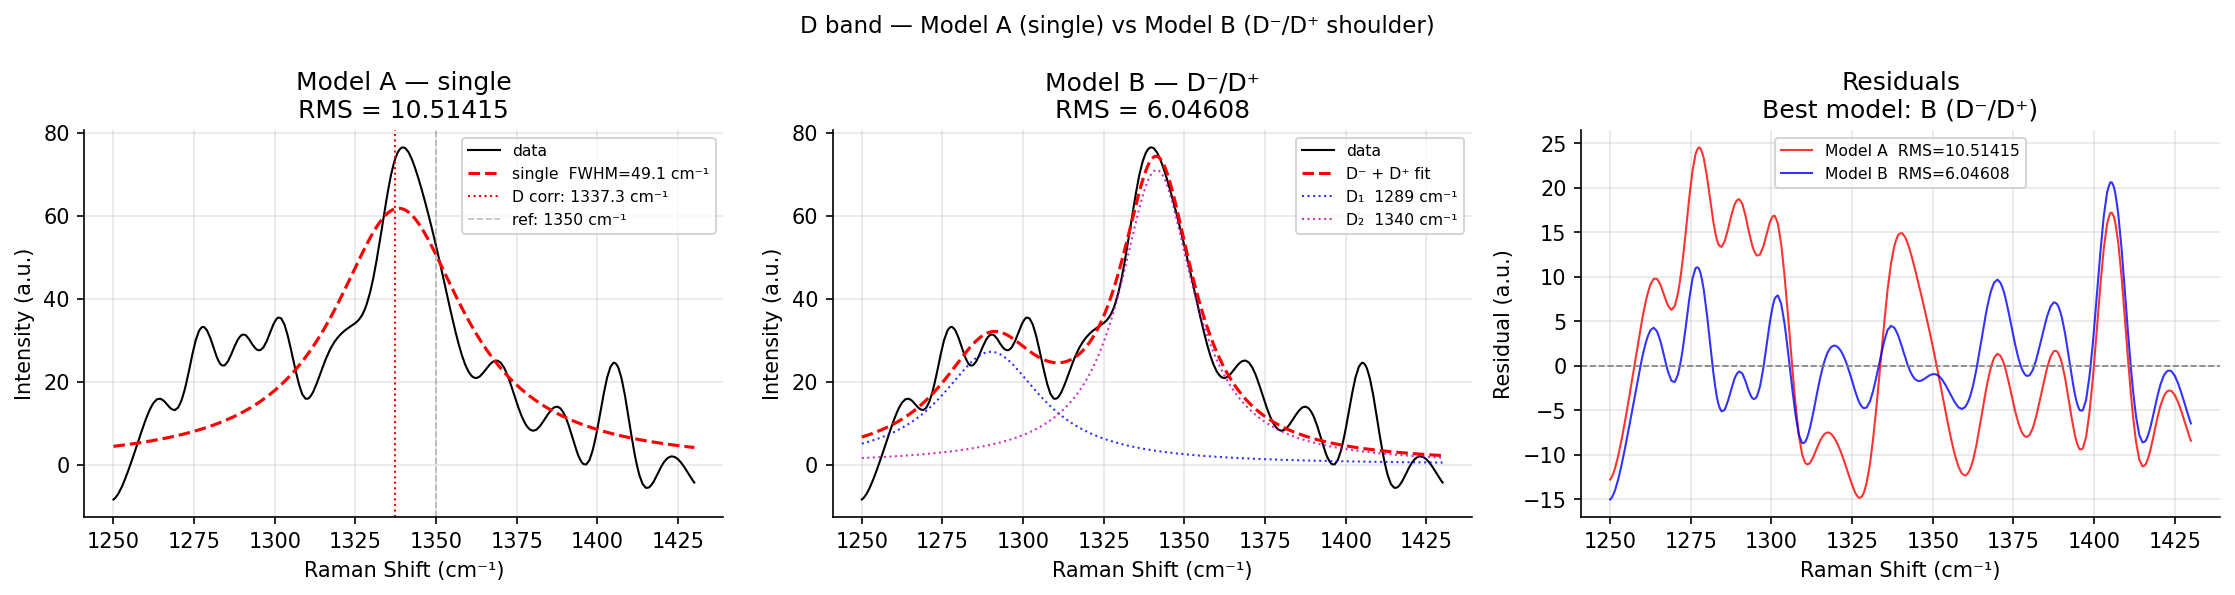

Saved: 03b_D_fit.png
  ✓ Saved 30 variable(s) → fit_results.npz
    ['d_amp', 'd_amp_err', 'd_cen_raw', 'd_cen_err', 'd_cen_corr', 'd_fwhm', 'd_fwhm_err', 'd_area', 'd_model', 'd_rms_modelA', 'd_rms_modelB', 'd_rms_improvement', 'd_amp_B1', 'd_cen_B1_corr', 'd_fwhm_B1', 'd_amp_B2', 'd_cen_B2_corr', 'd_fwhm_B2', 'd_shoulder_type', 'ratio_dg_amp', 'ratio_dg_area', 'ferrari_LD1_amp', 'ferrari_nD1_amp', 'ferrari_LD1_area', 'ferrari_nD1_area', 'ferrari_LD2_amp', 'ferrari_nD2_amp', 'ferrari_LD2_area', 'ferrari_nD2_area', 'EL']


In [64]:
# ── Cell 6: D band fit (~1350 cm⁻¹) ──────────────────────────────────────────
# The D band requires a defect for momentum conservation (intervalley
# scattering). Its presence indicates disorder, edges, or grain boundaries.
# Position is dispersive: shifts ~53 cm⁻¹/eV with laser energy.
# For 532 nm (2.33 eV): expected ~1340–1355 cm⁻¹.
#
# Models considered:
#   Model A — single Lorentzian
#             → typical for low-defect CVD graphene
#
#   Model B — two Lorentzians (D⁻ + D⁺)
#             → D⁻ at ~1320 cm⁻¹: tensile strain or heavy defects
#             → D⁺ at ~1370 cm⁻¹: oxidation / functionalisation
#             → asymmetric D band is the tell-tale sign
#
# Decision: Model B chosen only if RMS improves by > 10% AND
#           both components are physically reasonable.
#
# Naming convention:
#   d_amp, d_cen_raw, d_cen_corr, d_fwhm, d_area  → D band (best model)
#   d_amp_B1/B2, d_cen_B1/B2, d_fwhm_B1/B2        → two-component fit
#   d_model                                         → "single" or "double"
#   ratio_dg_amp, ratio_dg_area                    → I(D)/I(G) both conventions
#   ferrari_LD1_amp, ferrari_nD1_amp etc.          → defect density

REF_D  = 1350.0   # cm⁻¹, nominal reference
EL     = 2.33     # eV, 532 nm laser
EL4    = EL**4
IMPROVEMENT_THRESHOLD = 0.10   # 10%

# ── Safety checks ─────────────────────────────────────────────────────────────
if "CAL_OFFSET" not in dir():
    raise RuntimeError("CAL_OFFSET not defined — run calibration cell first.")
if "amp_G" not in dir():
    raise RuntimeError("amp_G not defined — run G band cell first.")

# ── Crop and baseline ─────────────────────────────────────────────────────────
wn_D, sp_D = rh.crop(wn, spec, 1250, 1430)
bl_D       = rh.linear_baseline(wn_D, sp_D, 1260, 1420)
sp_D_bl    = sp_D - bl_D

# ── Model A: single Lorentzian ────────────────────────────────────────────────
p0_A     = [sp_D_bl.max(), 1350, 40]
bounds_A = ([0, 1300, 10], [np.inf, 1400, 120])

fit_A_ok = False
try:
    popt_A, pcov_A = curve_fit(rh.lorentzian, wn_D, sp_D_bl,
                               p0=p0_A, bounds=bounds_A, maxfev=5000)
    perr_A                        = np.sqrt(np.diag(pcov_A))
    amp_A,     cen_A,     fwhm_A     = popt_A
    amp_A_err, cen_A_err, fwhm_A_err = perr_A
    fit_A      = rh.lorentzian(wn_D, *popt_A)
    resid_A    = sp_D_bl - fit_A
    rms_A      = np.sqrt(np.mean(resid_A**2))
    fit_A_ok   = True
    print(f"── Model A: single Lorentzian ───────────────────────────────────")
    print(f"  d_amp        : {amp_A:.2f} ± {amp_A_err:.2f}")
    print(f"  d_cen_raw    : {cen_A:.3f} ± {cen_A_err:.3f} cm⁻¹")
    print(f"  d_cen_corr   : {cen_A - CAL_OFFSET:.3f} cm⁻¹  "
          f"(expected ~1340–1355 cm⁻¹ for 532 nm)")
    print(f"  d_fwhm       : {fwhm_A:.3f} ± {fwhm_A_err:.3f} cm⁻¹")
    print(f"  RMS residual : {rms_A:.4f}")
except RuntimeError:
    print("  D band single fit failed — D band may be absent (very clean graphene)")

# ── Model B: two Lorentzians (D⁻ + D⁺) ───────────────────────────────────────
# D⁻ lower component  ~1320 cm⁻¹ (strain / heavy defects)
# D⁺ upper component  ~1370 cm⁻¹ (oxidation / functionalisation)
# Seed from Model A: main component + weaker secondary

def two_lorentzians(x, amp1, cen1, fwhm1, amp2, cen2, fwhm2):
    return rh.lorentzian(x, amp1, cen1, fwhm1) + \
           rh.lorentzian(x, amp2, cen2, fwhm2)

fit_B_ok = False
if fit_A_ok:
    p0_B     = [amp_A,       cen_A,        fwhm_A,
                amp_A * 0.3, cen_A + 20.0, fwhm_A * 0.7]
    bounds_B = ([0, 1290, 5,  0, 1310, 5],
                [np.inf, 1370, 100, np.inf, 1400, 100])
    try:
        popt_B, pcov_B = curve_fit(two_lorentzians, wn_D, sp_D_bl,
                                   p0=p0_B, bounds=bounds_B, maxfev=8000)
        perr_B = np.sqrt(np.diag(pcov_B))
        amp_B1,     cen_B1,     fwhm_B1     = popt_B[:3]
        amp_B2,     cen_B2,     fwhm_B2     = popt_B[3:]
        amp_B1_err, cen_B1_err, fwhm_B1_err = perr_B[:3]
        amp_B2_err, cen_B2_err, fwhm_B2_err = perr_B[3:]
        fit_B      = two_lorentzians(wn_D, *popt_B)
        resid_B    = sp_D_bl - fit_B
        rms_B      = np.sqrt(np.mean(resid_B**2))
        fit_B_ok   = True

        # Interpret which shoulder type
        split = abs(cen_B2 - cen_B1)
        if cen_B2 < cen_B1:
            shoulder_type = "D⁻ lower shoulder (~{:.0f} cm⁻¹) — strain/heavy defects".format(
                            cen_B2 - CAL_OFFSET)
        else:
            shoulder_type = "D⁺ upper shoulder (~{:.0f} cm⁻¹) — oxidation/functionalisation".format(
                            cen_B2 - CAL_OFFSET)

        print(f"\n── Model B: two Lorentzians ─────────────────────────────────────")
        print(f"  Component 1  : amp={amp_B1:.1f}  "
              f"cen={cen_B1 - CAL_OFFSET:.2f} cm⁻¹  fwhm={fwhm_B1:.1f} cm⁻¹")
        print(f"  Component 2  : amp={amp_B2:.1f}  "
              f"cen={cen_B2 - CAL_OFFSET:.2f} cm⁻¹  fwhm={fwhm_B2:.1f} cm⁻¹")
        print(f"  Split        : {split:.1f} cm⁻¹  →  {shoulder_type}")
        print(f"  RMS residual : {rms_B:.4f}")
    except RuntimeError:
        print("\n  Model B did not converge — single Lorentzian sufficient")

# ── Model comparison ──────────────────────────────────────────────────────────
print(f"\n── Model comparison ─────────────────────────────────────────────────")

if not fit_A_ok:
    # D band completely absent — very clean graphene
    best_model_D = "absent"
    amp_D  = 0.0;   amp_D_err  = 0.0
    cen_D  = REF_D; cen_D_err  = np.nan
    fwhm_D = np.nan; fwhm_D_err = np.nan
    rms_A  = np.nan; rms_B      = np.nan
    print("  D band absent — defect density below Raman detection limit")

elif fit_B_ok:
    improvement    = (rms_A - rms_B) / rms_A
    both_physical  = (fwhm_B1 > 5 and fwhm_B2 > 5 and
                      amp_B2 > 0.05 * amp_B1)

    print(f"  RMS Model A (single) : {rms_A:.5f}")
    print(f"  RMS Model B (double) : {rms_B:.5f}")
    print(f"  RMS improvement      : {100*improvement:.1f}%")
    print(f"  Both components OK   : {both_physical}")

    if improvement > IMPROVEMENT_THRESHOLD and both_physical:
        best_model_D = "double"
        print(f"  Decision : ✓ Model B — asymmetric D band, {shoulder_type}")
    else:
        best_model_D = "single"
        reason = "improvement < 10%" if improvement <= IMPROVEMENT_THRESHOLD \
                 else "second component unphysical"
        print(f"  Decision : Model A — {reason}")
else:
    best_model_D = "single"
    print(f"  RMS Model A (single) : {rms_A:.5f}")
    print(f"  Decision : Model A (Model B did not converge)")

# ── Assign final D band parameters ───────────────────────────────────────────
if best_model_D == "double":
    # Use stronger component as representative D band
    if amp_B1 >= amp_B2:
        amp_D,  amp_D_err  = amp_B1,  amp_B1_err
        cen_D,  cen_D_err  = cen_B1,  cen_B1_err
        fwhm_D, fwhm_D_err = fwhm_B1, fwhm_B1_err
    else:
        amp_D,  amp_D_err  = amp_B2,  amp_B2_err
        cen_D,  cen_D_err  = cen_B2,  cen_B2_err
        fwhm_D, fwhm_D_err = fwhm_B2, fwhm_B2_err
elif best_model_D == "single":
    amp_D,  amp_D_err  = amp_A,  amp_A_err
    cen_D,  cen_D_err  = cen_A,  cen_A_err
    fwhm_D, fwhm_D_err = fwhm_A, fwhm_A_err

if best_model_D != "absent":
    cen_D_corr    = cen_D - CAL_OFFSET
    area_D        = amp_D * fwhm_D * np.pi / 2
    ratio_dg_amp  = amp_D  / amp_G
    ratio_dg_area = area_D / area_G

    # Ferrari Stage 1 — amplitude and area ratios
    ferrari_LD1_amp,  ferrari_nD1_amp  = rh.ferrari_stage1(amp_D,  amp_G,  EL=EL)
    ferrari_LD1_area, ferrari_nD1_area = rh.ferrari_stage1(
                                             amp_D * fwhm_D,
                                             amp_G * fwhm_G, EL=EL)
    # Ferrari Stage 2
    ferrari_LD2_amp,  ferrari_nD2_amp  = rh.ferrari_stage2(amp_D,  amp_G,  EL=EL)
    ferrari_LD2_area, ferrari_nD2_area = rh.ferrari_stage2(
                                             amp_D * fwhm_D,
                                             amp_G * fwhm_G, EL=EL)

    # Stage verdict
    def stage_verdict(LD):
        if LD > 10:   return "✓ Stage 1 valid  (L_D > 10 nm)"
        elif LD > 3:  return "⚠ borderline     (3–10 nm)"
        else:         return "✗ Stage 2 valid  (L_D < 3 nm)"

    print(f"\n── Final D band parameters ──────────────────────────────────────")
    print(f"  d_amp         : {amp_D:.2f} ± {amp_D_err:.2f}")
    print(f"  d_cen_raw     : {cen_D:.3f} ± {cen_D_err:.3f} cm⁻¹")
    print(f"  d_cen_corr    : {cen_D_corr:.3f} cm⁻¹")
    print(f"  d_fwhm        : {fwhm_D:.3f} cm⁻¹")
    print(f"\n── Intensity ratios ─────────────────────────────────────────────")
    print(f"  {'':20} {'Amplitude':>12} {'Area':>12}")
    print(f"  {'I(D)/I(G)':<20} {ratio_dg_amp:>12.4f} {ratio_dg_area:>12.4f}")
    print(f"\n── Ferrari Stage 1 (E_L = {EL} eV) ──────────────────────────────")
    print(f"  {'':20} {'Amplitude':>12} {'Area':>12}")
    print(f"  {'L_D (nm)':<20} {ferrari_LD1_amp:>12.2f} {ferrari_LD1_area:>12.2f}")
    print(f"  {'n_D (cm⁻²)':<20} {ferrari_nD1_amp:>12.3e} {ferrari_nD1_area:>12.3e}")
    print(f"  Amplitude → {stage_verdict(ferrari_LD1_amp)}")
    print(f"  Area      → {stage_verdict(ferrari_LD1_area)}")

else:
    cen_D_corr    = np.nan
    area_D        = np.nan
    ratio_dg_amp  = 0.0
    ratio_dg_area = 0.0
    ferrari_LD1_amp = ferrari_nD1_amp = np.nan
    ferrari_LD1_area= ferrari_nD1_area= np.nan
    ferrari_LD2_amp = ferrari_nD2_amp = np.nan
    ferrari_LD2_area= ferrari_nD2_area= np.nan

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("D band — Model A (single) vs Model B (D⁻/D⁺ shoulder)",
             fontsize=11)

# Left: Model A
ax = axes[0]
ax.plot(wn_D, sp_D_bl, "k", lw=1, label="data")
if fit_A_ok:
    ax.plot(wn_D, fit_A, "r--", lw=1.5,
            label=f"single  FWHM={fwhm_A:.1f} cm⁻¹")
    ax.axvline(cen_A - CAL_OFFSET, color="red", lw=1, ls=":",
               label=f"D corr: {cen_A - CAL_OFFSET:.1f} cm⁻¹")
ax.axvline(REF_D, color="grey", lw=0.8, ls="--",
           alpha=0.5, label=f"ref: {REF_D:.0f} cm⁻¹")
ax.set_title(f"Model A — single\n"
             f"{'RMS = ' + f'{rms_A:.5f}' if fit_A_ok else 'D band absent'}")
ax.set_xlabel("Raman Shift (cm⁻¹)")
ax.set_ylabel("Intensity (a.u.)")
ax.legend(fontsize=7.5)

# Middle: Model B
ax = axes[1]
ax.plot(wn_D, sp_D_bl, "k", lw=1, label="data")
if fit_B_ok:
    ax.plot(wn_D, fit_B, "r--", lw=1.5, label="D⁻ + D⁺ fit")
    ax.plot(wn_D, rh.lorentzian(wn_D, amp_B1, cen_B1, fwhm_B1),
            "b:", lw=1, alpha=0.8,
            label=f"D₁  {cen_B1 - CAL_OFFSET:.0f} cm⁻¹")
    ax.plot(wn_D, rh.lorentzian(wn_D, amp_B2, cen_B2, fwhm_B2),
            "m:", lw=1, alpha=0.8,
            label=f"D₂  {cen_B2 - CAL_OFFSET:.0f} cm⁻¹")
    ax.set_title(f"Model B — D⁻/D⁺\nRMS = {rms_B:.5f}")
else:
    ax.set_title("Model B — did not converge")
ax.set_xlabel("Raman Shift (cm⁻¹)")
ax.set_ylabel("Intensity (a.u.)")
ax.legend(fontsize=7.5)

# Right: residuals
ax = axes[2]
if fit_A_ok:
    ax.plot(wn_D, resid_A, "r-", lw=1, alpha=0.8,
            label=f"Model A  RMS={rms_A:.5f}")
if fit_B_ok:
    ax.plot(wn_D, resid_B, "b-", lw=1, alpha=0.8,
            label=f"Model B  RMS={rms_B:.5f}")
ax.axhline(0, color="grey", lw=0.8, ls="--")
winner = ("B (D⁻/D⁺)" if best_model_D == "double" else
          "A (single)" if best_model_D == "single" else
          "absent")
ax.set_title(f"Residuals\nBest model: {winner}")
ax.set_xlabel("Raman Shift (cm⁻¹)")
ax.set_ylabel("Residual (a.u.)")
ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig("03b_D_fit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 03b_D_fit.png")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    # D band — best model representative values
    d_amp             = amp_D,
    d_amp_err         = amp_D_err,
    d_cen_raw         = cen_D,
    d_cen_err         = cen_D_err,
    d_cen_corr        = cen_D_corr,
    d_fwhm            = fwhm_D,
    d_fwhm_err        = fwhm_D_err,
    d_area            = area_D,
    d_model           = best_model_D,
    # Model comparison
    d_rms_modelA      = rms_A,
    d_rms_modelB      = rms_B      if fit_B_ok else np.nan,
    d_rms_improvement = (rms_A - rms_B) / rms_A if fit_B_ok else np.nan,
    # Two-component parameters (NaN if single/absent)
    d_amp_B1          = amp_B1     if fit_B_ok else np.nan,
    d_cen_B1_corr     = cen_B1 - CAL_OFFSET if fit_B_ok else np.nan,
    d_fwhm_B1         = fwhm_B1    if fit_B_ok else np.nan,
    d_amp_B2          = amp_B2     if fit_B_ok else np.nan,
    d_cen_B2_corr     = cen_B2 - CAL_OFFSET if fit_B_ok else np.nan,
    d_fwhm_B2         = fwhm_B2    if fit_B_ok else np.nan,
    d_shoulder_type   = shoulder_type if fit_B_ok else "N/A",
    # Intensity ratios
    ratio_dg_amp      = ratio_dg_amp,
    ratio_dg_area     = ratio_dg_area,
    # Ferrari Stage 1
    ferrari_LD1_amp   = ferrari_LD1_amp,
    ferrari_nD1_amp   = ferrari_nD1_amp,
    ferrari_LD1_area  = ferrari_LD1_area,
    ferrari_nD1_area  = ferrari_nD1_area,
    # Ferrari Stage 2
    ferrari_LD2_amp   = ferrari_LD2_amp,
    ferrari_nD2_amp   = ferrari_nD2_amp,
    ferrari_LD2_area  = ferrari_LD2_area,
    ferrari_nD2_area  = ferrari_nD2_area,
    # Laser energy used
    EL                = EL,
)

── Contamination feature at ~1407 cm⁻¹ ─────────────────────────────
  mean intensity above baseline : 11.1 counts
  max  intensity above baseline : 21.3 counts
  % spectra with signal > 10    : 66%

── Correlation with D band ───────────────────────────────────────────
  Pearson r (D amp vs 1407 feature) : -0.110
  → Independent of defect density — contamination confirmed


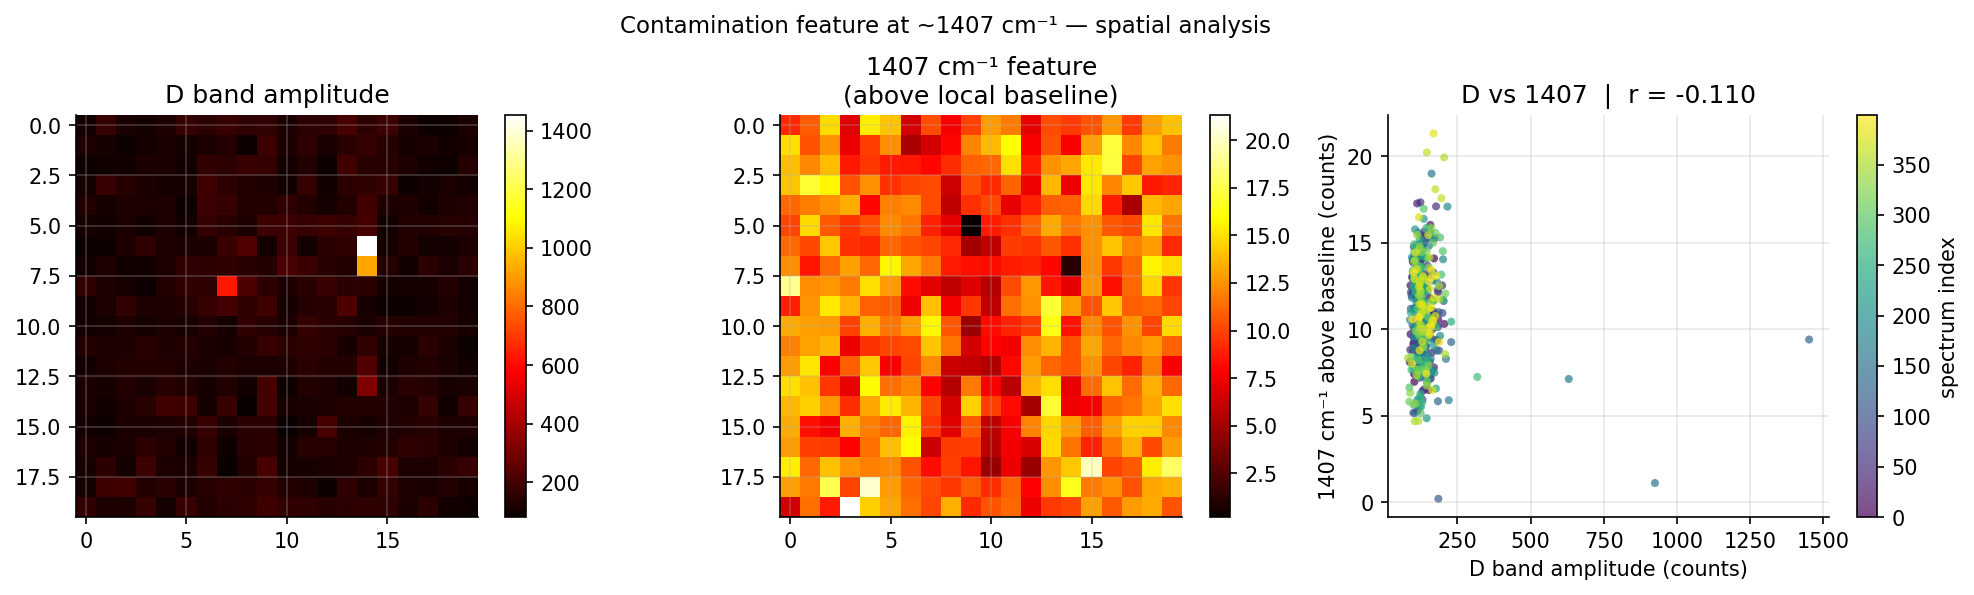

Saved: contam_1407_spatial.png
  ✓ Saved 6 variable(s) → fit_results.npz
    ['contam_wn', 'contam_mean_int', 'contam_max_int', 'contam_D_corr', 'contam_coverage_pct', 'contam_assignment']


In [69]:
# ── Contamination check — residual MMA monomer at ~1407 cm⁻¹ ─────────────────
# C=CH₂ bending mode of unconverted methacrylate monomer from PMMA transfer.
# Correlation with D band confirms it is independent of graphene defect density.

# ── Detection windows ─────────────────────────────────────────────────────────
# Peak window  : 1400–1415 cm⁻¹  (centred on 1407)
# Baseline window: 1420–1440 cm⁻¹ (flat region between feature and G band,
#                                   far enough from D tail and G band wings)

mask_1407     = (wn >= 1400) & (wn <= 1415)
mask_baseline = (wn >= 1420) & (wn <= 1440)

intensity_1407 = spectra[mask_1407, :].max(axis=0)
baseline_1407  = spectra[mask_baseline, :].mean(axis=0)
above_baseline = intensity_1407 - baseline_1407

print(f"── Contamination feature at ~1407 cm⁻¹ ─────────────────────────────")
print(f"  mean intensity above baseline : {above_baseline.mean():.1f} counts")
print(f"  max  intensity above baseline : {above_baseline.max():.1f} counts")
print(f"  % spectra with signal > 10    : {100*np.mean(above_baseline > 10):.0f}%")

# ── Spatial correlation with D band ──────────────────────────────────────────
mask_D_peak  = (wn >= 1330) & (wn <= 1370)
intensity_D  = spectra[mask_D_peak, :].max(axis=0)
correlation  = np.corrcoef(intensity_D, above_baseline)[0, 1]

print(f"\n── Correlation with D band ───────────────────────────────────────────")
print(f"  Pearson r (D amp vs 1407 feature) : {correlation:.3f}")
if correlation > 0.8:
    print(f"  → D band tail — not a separate feature")
elif correlation < 0.5:
    print(f"  → Independent of defect density — contamination confirmed")
else:
    print(f"  → Ambiguous — inspect spatial maps")

# ── Spatial maps ──────────────────────────────────────────────────────────────
NX, NY = 20, 20
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Contamination feature at ~1407 cm⁻¹ — spatial analysis",
             fontsize=11)

im0 = axes[0].imshow(intensity_D.reshape(NY, NX),
                     origin="upper", cmap="hot")
axes[0].set_title("D band amplitude")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(above_baseline.reshape(NY, NX),
                     origin="upper", cmap="hot")
axes[1].set_title("1407 cm⁻¹ feature\n(above local baseline)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Scatter: D band vs 1407 feature coloured by map position
sc = axes[2].scatter(intensity_D, above_baseline,
                     c=np.arange(400), cmap="viridis",
                     s=15, alpha=0.7, edgecolors="none")
plt.colorbar(sc, ax=axes[2], label="spectrum index")
axes[2].set_xlabel("D band amplitude (counts)")
axes[2].set_ylabel("1407 cm⁻¹ above baseline (counts)")
axes[2].set_title(f"D vs 1407  |  r = {correlation:.3f}")

plt.tight_layout()
plt.savefig("contam_1407_spatial.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: contam_1407_spatial.png")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    contam_wn           = 1407.0,
    contam_mean_int     = float(above_baseline.mean()),
    contam_max_int      = float(above_baseline.max()),
    contam_D_corr       = float(correlation),
    contam_coverage_pct = float(100 * np.mean(above_baseline > 10)),
    contam_assignment   = "Residual MMA monomer / PMMA oligomer — C=CH2 bending",
)

════════════════════════════════════════════════════════════
  FEATURE 1 — Si 2TO overtone (~960 cm⁻¹)
════════════════════════════════════════════════════════════

── Model A: single Lorentzian ───────────────────────────────────
  si2to_amp      : 308.06 ± 5.11
  si2to_cen      : 967.09 ± 0.44 cm⁻¹
  si2to_fwhm     : 53.86 ± 1.31 cm⁻¹
  RMS residual   : 32.7719

── Model B: three Lorentzians ───────────────────────────────────
  2TO(X) : amp=145.7  cen=941.2 cm⁻¹  fwhm=16.4 cm⁻¹
  2TO(W) : amp=161.5  cen=957.3 cm⁻¹  fwhm=24.7 cm⁻¹
  2TO(L) : amp=251.9  cen=980.8 cm⁻¹  fwhm=31.1 cm⁻¹
  RMS residual : 11.0904

── Model comparison ─────────────────────────────────────────────
  RMS Model A : 32.77188
  RMS Model B : 11.09040
  Improvement : 66.2%
  Decision    : ✓ Model B (triple)

════════════════════════════════════════════════════════════
  FEATURE 2 — D+D" combination mode (~2650 cm⁻¹)
════════════════════════════════════════════════════════════

── D+D" fit ────────────────────────

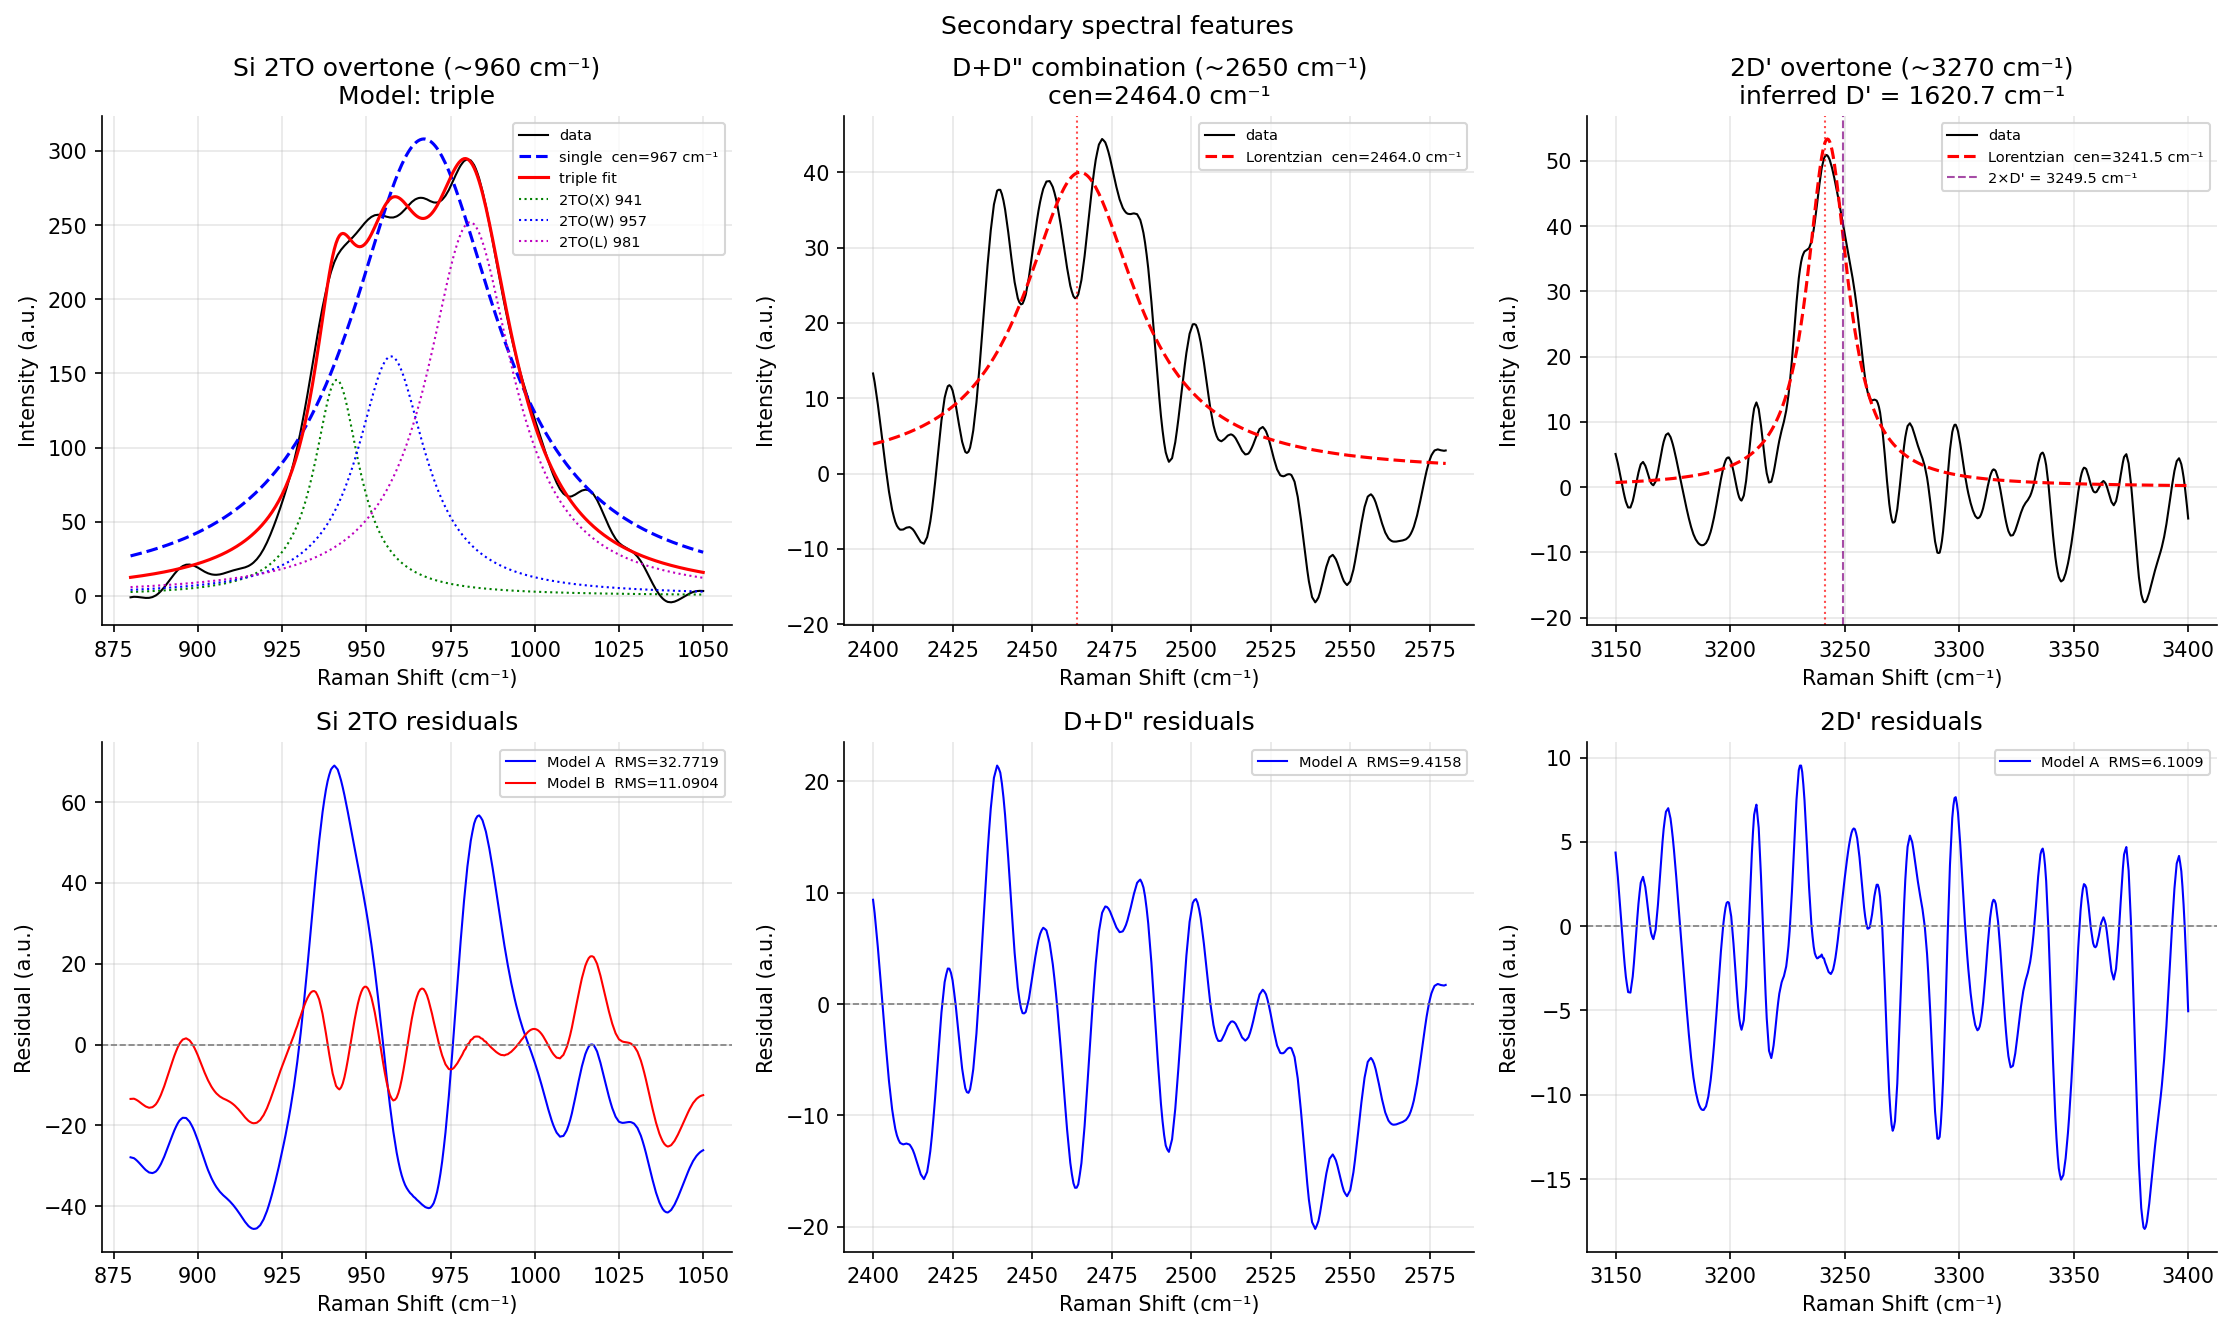

Saved: 07_secondary_features.png
  ✓ Saved 22 variable(s) → fit_results.npz
    ['si2to_amp', 'si2to_cen', 'si2to_fwhm', 'si2to_model', 'si2to_rms_A', 'si2to_rms_B', 'si2to_cen_X', 'si2to_cen_W', 'si2to_cen_L', 'ddp_amp', 'ddp_cen_raw', 'ddp_cen_corr', 'ddp_fwhm', 'ddp_area', 'ddp_rms', 'tdp_amp', 'tdp_cen_raw', 'tdp_cen_corr', 'tdp_fwhm', 'tdp_area', 'tdp_rms', 'tdp_inferred_Dp']


In [70]:
# ── Cell 7: Secondary features — Si 2TO, D+D", 2D' ───────────────────────────
# Three additional spectral features visible in the data, each with
# distinct physical origins:
#
# ~960 cm⁻¹  — Si 2TO overtone (substrate, always present)
#   Second-order overtone of Si transverse optical phonon.
#   Broad because all Brillouin zone phonons contribute to second-order scattering.
#   Components: 2TO(X) ~930, 2TO(W) ~960, 2TO(L) ~985 cm⁻¹
#   Fit with three Lorentzians or one broad Lorentzian depending on resolution.
#
# ~2650 cm⁻¹ — D+D" combination mode (graphene intrinsic)
#   Combination of D phonon + D" acoustic phonon branch.
#   Dispersive: position shifts with laser energy (~2650 cm⁻¹ at 532 nm).
#   Sits just below the 2D band — must be isolated carefully.
#   Presence indicates good crystallinity (double resonance process).
#
# ~3270 cm⁻¹ — 2D' overtone (graphene intrinsic)
#   Overtone of D' band (~1625 cm⁻¹): expected at ~2 × 1625 = 3250 cm⁻¹
#   dispersive shift brings it to ~3270 cm⁻¹ at 532 nm.
#   Cross-check: 3270/2 = 1635 cm⁻¹ should match fitted D' centre.
#   Present even in defect-free graphene (same selection rules as 2D).
#
# Naming convention:
#   si2to_*      → Si 2TO overtone
#   ddp_*        → D+D" combination mode
#   tdp_*        → 2D' overtone

# ── Safety checks ─────────────────────────────────────────────────────────────
if "CAL_OFFSET" not in dir():
    raise RuntimeError("CAL_OFFSET not defined — run calibration cell first.")
if "cen_Dp" not in dir() or np.isnan(cen_Dp):
    print("⚠ D' centre not available — 2D' cross-check will be skipped")
    dp_available = False
else:
    dp_available = True

IMPROVEMENT_THRESHOLD = 0.10   # 10% — consistent with other cells

# ══════════════════════════════════════════════════════════════════════════════
# FEATURE 1 — Si 2TO overtone (~960 cm⁻¹)
# ══════════════════════════════════════════════════════════════════════════════
# The 2TO multiplet has three overlapping components. We try:
#   Model A — single broad Lorentzian (sufficient if components unresolved)
#   Model B — three Lorentzians (2TO(X) ~930, 2TO(W) ~960, 2TO(L) ~985)

print("═"*60)
print("  FEATURE 1 — Si 2TO overtone (~960 cm⁻¹)")
print("═"*60)

wn_2TO, sp_2TO = rh.crop(wn, spec, 880, 1050)
bl_2TO         = rh.linear_baseline(wn_2TO, sp_2TO, 890, 1040)
sp_2TO_bl      = sp_2TO - bl_2TO

# Model A — single Lorentzian
p0_2TO_A     = [sp_2TO_bl.max(), 960, 60]
bounds_2TO_A = ([0, 920, 20], [np.inf, 1000, 150])

fit_2TO_A_ok = False
try:
    popt_2TO_A, pcov_2TO_A = curve_fit(
        rh.lorentzian, wn_2TO, sp_2TO_bl,
        p0=p0_2TO_A, bounds=bounds_2TO_A, maxfev=5000)
    perr_2TO_A = np.sqrt(np.diag(pcov_2TO_A))
    amp_2TO_A, cen_2TO_A, fwhm_2TO_A = popt_2TO_A
    fit_2TO_A  = rh.lorentzian(wn_2TO, *popt_2TO_A)
    resid_2TO_A= sp_2TO_bl - fit_2TO_A
    rms_2TO_A  = np.sqrt(np.mean(resid_2TO_A**2))
    fit_2TO_A_ok = True
    print(f"\n── Model A: single Lorentzian ───────────────────────────────────")
    print(f"  si2to_amp      : {amp_2TO_A:.2f} ± {perr_2TO_A[0]:.2f}")
    print(f"  si2to_cen      : {cen_2TO_A:.2f} ± {perr_2TO_A[1]:.2f} cm⁻¹")
    print(f"  si2to_fwhm     : {fwhm_2TO_A:.2f} ± {perr_2TO_A[2]:.2f} cm⁻¹")
    print(f"  RMS residual   : {rms_2TO_A:.4f}")
except RuntimeError:
    print("  Si 2TO single fit failed")

# Model B — three Lorentzians (2TO(X), 2TO(W), 2TO(L))
def three_lorentzians(x, a1,c1,f1, a2,c2,f2, a3,c3,f3):
    return (rh.lorentzian(x,a1,c1,f1) +
            rh.lorentzian(x,a2,c2,f2) +
            rh.lorentzian(x,a3,c3,f3))

fit_2TO_B_ok = False
if fit_2TO_A_ok:
    p0_2TO_B = [
        amp_2TO_A*0.6, 935, 25,   # 2TO(X)
        amp_2TO_A,     960, 25,   # 2TO(W)  — dominant
        amp_2TO_A*0.4, 985, 25,   # 2TO(L)
    ]
    bounds_2TO_B = (
        [0, 910, 5,  0, 940, 5,  0, 965, 5],
        [np.inf, 945, 60, np.inf, 975, 60, np.inf, 1005, 60]
    )
    try:
        popt_2TO_B, pcov_2TO_B = curve_fit(
            three_lorentzians, wn_2TO, sp_2TO_bl,
            p0=p0_2TO_B, bounds=bounds_2TO_B, maxfev=10000)
        perr_2TO_B  = np.sqrt(np.diag(pcov_2TO_B))
        fit_2TO_B   = three_lorentzians(wn_2TO, *popt_2TO_B)
        resid_2TO_B = sp_2TO_bl - fit_2TO_B
        rms_2TO_B   = np.sqrt(np.mean(resid_2TO_B**2))
        fit_2TO_B_ok = True

        amp_X,  cen_X,  fwhm_X  = popt_2TO_B[0:3]
        amp_W,  cen_W,  fwhm_W  = popt_2TO_B[3:6]
        amp_L,  cen_L,  fwhm_L  = popt_2TO_B[6:9]

        print(f"\n── Model B: three Lorentzians ───────────────────────────────────")
        print(f"  2TO(X) : amp={amp_X:.1f}  cen={cen_X:.1f} cm⁻¹  fwhm={fwhm_X:.1f} cm⁻¹")
        print(f"  2TO(W) : amp={amp_W:.1f}  cen={cen_W:.1f} cm⁻¹  fwhm={fwhm_W:.1f} cm⁻¹")
        print(f"  2TO(L) : amp={amp_L:.1f}  cen={cen_L:.1f} cm⁻¹  fwhm={fwhm_L:.1f} cm⁻¹")
        print(f"  RMS residual : {rms_2TO_B:.4f}")
    except RuntimeError:
        print("  Model B (three Lorentzians) did not converge")

# Model comparison
if fit_2TO_A_ok and fit_2TO_B_ok:
    improvement_2TO = (rms_2TO_A - rms_2TO_B) / rms_2TO_A
    print(f"\n── Model comparison ─────────────────────────────────────────────")
    print(f"  RMS Model A : {rms_2TO_A:.5f}")
    print(f"  RMS Model B : {rms_2TO_B:.5f}")
    print(f"  Improvement : {100*improvement_2TO:.1f}%")
    best_2TO = "triple" if improvement_2TO > IMPROVEMENT_THRESHOLD else "single"
    print(f"  Decision    : {'✓ Model B (triple)' if best_2TO == 'triple' else 'Model A (single)'}")
elif fit_2TO_A_ok:
    best_2TO = "single"
    improvement_2TO = np.nan

# Assign final Si 2TO parameters
if best_2TO == "triple" and fit_2TO_B_ok:
    si2to_amp  = amp_W;   si2to_cen  = cen_W;   si2to_fwhm  = fwhm_W
else:
    si2to_amp  = amp_2TO_A; si2to_cen = cen_2TO_A; si2to_fwhm = fwhm_2TO_A


# ══════════════════════════════════════════════════════════════════════════════
# FEATURE 2 — D+D" combination mode (~2650 cm⁻¹)
# ══════════════════════════════════════════════════════════════════════════════
# Sits just below the 2D band. Fit window must be carefully chosen to
# avoid the low-wavenumber wing of the 2D band (~2620 cm⁻¹ onset).
# Single Lorentzian — no known splitting.

print("\n" + "═"*60)
print("  FEATURE 2 — D+D\" combination mode (~2650 cm⁻¹)")
print("═"*60)

wn_DDp, sp_DDp = rh.crop(wn, spec, 2400, 2580)
bl_DDp         = rh.linear_baseline(wn_DDp, sp_DDp, 2410, 2570)
sp_DDp_bl      = sp_DDp - bl_DDp

p0_DDp     = [sp_DDp_bl.max(), 2450, 40]
bounds_DDp = ([0, 2400, 10], [np.inf, 2560, 120])

fit_DDp_ok = False
try:
    popt_DDp, pcov_DDp = curve_fit(
        rh.lorentzian, wn_DDp, sp_DDp_bl,
        p0=p0_DDp, bounds=bounds_DDp, maxfev=5000)
    perr_DDp = np.sqrt(np.diag(pcov_DDp))
    amp_DDp, cen_DDp, fwhm_DDp = popt_DDp
    cen_DDp_corr = cen_DDp - CAL_OFFSET
    area_DDp     = amp_DDp * fwhm_DDp * np.pi / 2
    fit_DDp      = rh.lorentzian(wn_DDp, *popt_DDp)
    resid_DDp    = sp_DDp_bl - fit_DDp
    rms_DDp      = np.sqrt(np.mean(resid_DDp**2))
    fit_DDp_ok   = True

    print(f"\n── D+D\" fit ──────────────────────────────────────────────────────")
    print(f"  ddp_amp      : {amp_DDp:.2f} ± {perr_DDp[0]:.2f}")
    print(f"  ddp_cen_raw  : {cen_DDp:.3f} ± {perr_DDp[1]:.3f} cm⁻¹")
    print(f"  ddp_cen_corr : {cen_DDp_corr:.3f} cm⁻¹")
    print(f"  ddp_fwhm     : {fwhm_DDp:.3f} ± {perr_DDp[2]:.3f} cm⁻¹")
    print(f"  ddp_area     : {area_DDp:.1f}")
    print(f"  RMS residual : {rms_DDp:.4f}")
except RuntimeError:
    print("  D+D\" fit failed — feature may be too weak to resolve")
    amp_DDp = cen_DDp = fwhm_DDp = np.nan
    cen_DDp_corr = area_DDp = rms_DDp = np.nan


# ══════════════════════════════════════════════════════════════════════════════
# FEATURE 3 — 2D' overtone (~3270 cm⁻¹)
# ══════════════════════════════════════════════════════════════════════════════
# Overtone of D' (~1625 cm⁻¹). Expected at ~2 × cen_Dp.
# Cross-check: fitted centre / 2 should match cen_Dp from G band cell.
# Single Lorentzian — no known splitting.

print("\n" + "═"*60)
print("  FEATURE 3 — 2D' overtone (~3270 cm⁻¹)")
print("═"*60)

wn_2Dp, sp_2Dp = rh.crop(wn, spec, 3150, 3400)
bl_2Dp         = rh.linear_baseline(wn_2Dp, sp_2Dp, 3160, 3390)
sp_2Dp_bl      = sp_2Dp - bl_2Dp

p0_2Dp     = [sp_2Dp_bl.max(), 3270, 40]
bounds_2Dp = ([0, 3180, 10], [np.inf, 3380, 120])

fit_2Dp_ok = False
try:
    popt_2Dp, pcov_2Dp = curve_fit(
        rh.lorentzian, wn_2Dp, sp_2Dp_bl,
        p0=p0_2Dp, bounds=bounds_2Dp, maxfev=5000)
    perr_2Dp = np.sqrt(np.diag(pcov_2Dp))
    amp_2Dp, cen_2Dp, fwhm_2Dp = popt_2Dp
    cen_2Dp_corr  = cen_2Dp - CAL_OFFSET
    area_2Dp      = amp_2Dp * fwhm_2Dp * np.pi / 2
    inferred_Dp   = cen_2Dp_corr / 2   # should match cen_Dp_corr
    fit_2Dp       = rh.lorentzian(wn_2Dp, *popt_2Dp)
    resid_2Dp     = sp_2Dp_bl - fit_2Dp
    rms_2Dp       = np.sqrt(np.mean(resid_2Dp**2))
    fit_2Dp_ok    = True

    print(f"\n── 2D' fit ───────────────────────────────────────────────────────")
    print(f"  tdp_amp        : {amp_2Dp:.2f} ± {perr_2Dp[0]:.2f}")
    print(f"  tdp_cen_raw    : {cen_2Dp:.3f} ± {perr_2Dp[1]:.3f} cm⁻¹")
    print(f"  tdp_cen_corr   : {cen_2Dp_corr:.3f} cm⁻¹")
    print(f"  tdp_fwhm       : {fwhm_2Dp:.3f} ± {perr_2Dp[2]:.3f} cm⁻¹")
    print(f"  tdp_area       : {area_2Dp:.1f}")
    print(f"  RMS residual   : {rms_2Dp:.4f}")

    # Cross-check with fitted D' centre from G band cell
    print(f"\n── 2D' → D' cross-check ─────────────────────────────────────────")
    print(f"  2D' centre / 2      : {inferred_Dp:.2f} cm⁻¹  (inferred D')")
    if dp_available:
        direct_Dp  = cen_Dp - CAL_OFFSET
        discrepancy = abs(inferred_Dp - direct_Dp)
        print(f"  D' from G+D' fit    : {direct_Dp:.2f} cm⁻¹")
        print(f"  Discrepancy         : {discrepancy:.2f} cm⁻¹")
        if discrepancy < 5:
            print(f"  ✓ Consistent — 2D' overtone assignment confirmed")
        else:
            print(f"  ⚠ Discrepancy > 5 cm⁻¹ — check fits")
    else:
        print(f"  D' direct fit not available for comparison")

except RuntimeError:
    print("  2D' fit failed — feature may be too weak to resolve")
    amp_2Dp = cen_2Dp = fwhm_2Dp = np.nan
    cen_2Dp_corr = area_2Dp = inferred_Dp = rms_2Dp = np.nan

# ══════════════════════════════════════════════════════════════════════════════
# PLOT — all three features
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Secondary spectral features", fontsize=12)

# ── Row 1: data + fits ────────────────────────────────────────────────────────

# Si 2TO
ax = axes[0, 0]
ax.plot(wn_2TO, sp_2TO_bl, "k", lw=1, label="data")
if fit_2TO_A_ok:
    ax.plot(wn_2TO, fit_2TO_A, "b--", lw=1.5,
            label=f"single  cen={cen_2TO_A:.0f} cm⁻¹")
if fit_2TO_B_ok and best_2TO == "triple":
    ax.plot(wn_2TO, fit_2TO_B, "r-", lw=1.5, label="triple fit")
    ax.plot(wn_2TO, rh.lorentzian(wn_2TO, amp_X, cen_X, fwhm_X),
            "g:", lw=1, label=f"2TO(X) {cen_X:.0f}")
    ax.plot(wn_2TO, rh.lorentzian(wn_2TO, amp_W, cen_W, fwhm_W),
            "b:", lw=1, label=f"2TO(W) {cen_W:.0f}")
    ax.plot(wn_2TO, rh.lorentzian(wn_2TO, amp_L, cen_L, fwhm_L),
            "m:", lw=1, label=f"2TO(L) {cen_L:.0f}")
ax.set_title(f"Si 2TO overtone (~960 cm⁻¹)\nModel: {best_2TO}")
ax.set_xlabel("Raman Shift (cm⁻¹)")
ax.set_ylabel("Intensity (a.u.)")
ax.legend(fontsize=7)

# D+D"
ax = axes[0, 1]
ax.plot(wn_DDp, sp_DDp_bl, "k", lw=1, label="data")
if fit_DDp_ok:
    ax.plot(wn_DDp, fit_DDp, "r--", lw=1.5,
            label=f"Lorentzian  cen={cen_DDp_corr:.1f} cm⁻¹")
    ax.axvline(cen_DDp_corr, color="red", lw=1, ls=":", alpha=0.7)
ax.set_title(f"D+D\" combination (~2650 cm⁻¹)\n"
             f"{'cen=' + f'{cen_DDp_corr:.1f} cm⁻¹' if fit_DDp_ok else 'fit failed'}")
ax.set_xlabel("Raman Shift (cm⁻¹)")
ax.set_ylabel("Intensity (a.u.)")
ax.legend(fontsize=7)

# 2D'
ax = axes[0, 2]
ax.plot(wn_2Dp, sp_2Dp_bl, "k", lw=1, label="data")
if fit_2Dp_ok:
    ax.plot(wn_2Dp, fit_2Dp, "r--", lw=1.5,
            label=f"Lorentzian  cen={cen_2Dp_corr:.1f} cm⁻¹")
    ax.axvline(cen_2Dp_corr, color="red", lw=1, ls=":", alpha=0.7)
    if dp_available:
        ax.axvline(2*(cen_Dp - CAL_OFFSET), color="purple", lw=1,
                   ls="--", alpha=0.7,
                   label=f"2×D' = {2*(cen_Dp-CAL_OFFSET):.1f} cm⁻¹")
ax.set_title(f"2D' overtone (~3270 cm⁻¹)\n"
             f"{'inferred D' + chr(39) + f' = {inferred_Dp:.1f} cm⁻¹' if fit_2Dp_ok else 'fit failed'}")
ax.set_xlabel("Raman Shift (cm⁻¹)")
ax.set_ylabel("Intensity (a.u.)")
ax.legend(fontsize=7)

# ── Row 2: residuals ──────────────────────────────────────────────────────────
for col, (wn_r, resid_A, resid_B, ok_A, ok_B, label) in enumerate([
    (wn_2TO, resid_2TO_A if fit_2TO_A_ok else None,
             resid_2TO_B if fit_2TO_B_ok else None,
             fit_2TO_A_ok, fit_2TO_B_ok, "Si 2TO"),
    (wn_DDp, resid_DDp   if fit_DDp_ok  else None,
             None, fit_DDp_ok, False, "D+D\""),
    (wn_2Dp, resid_2Dp   if fit_2Dp_ok  else None,
             None, fit_2Dp_ok, False, "2D'"),
]):
    ax = axes[1, col]
    if ok_A and resid_A is not None:
        rms_val = np.sqrt(np.mean(resid_A**2))
        ax.plot(wn_r, resid_A, "b-", lw=1,
                label=f"Model A  RMS={rms_val:.4f}")
    if ok_B and resid_B is not None:
        rms_val_B = np.sqrt(np.mean(resid_B**2))
        ax.plot(wn_r, resid_B, "r-", lw=1,
                label=f"Model B  RMS={rms_val_B:.4f}")
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.set_title(f"{label} residuals")
    ax.set_xlabel("Raman Shift (cm⁻¹)")
    ax.set_ylabel("Residual (a.u.)")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("07_secondary_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07_secondary_features.png")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    # Si 2TO
    si2to_amp         = si2to_amp,
    si2to_cen         = si2to_cen,
    si2to_fwhm        = si2to_fwhm,
    si2to_model       = best_2TO,
    si2to_rms_A       = rms_2TO_A  if fit_2TO_A_ok else np.nan,
    si2to_rms_B       = rms_2TO_B  if fit_2TO_B_ok else np.nan,
    si2to_cen_X       = cen_X      if fit_2TO_B_ok else np.nan,
    si2to_cen_W       = cen_W      if fit_2TO_B_ok else np.nan,
    si2to_cen_L       = cen_L      if fit_2TO_B_ok else np.nan,
    # D+D" combination
    ddp_amp           = amp_DDp,
    ddp_cen_raw       = cen_DDp,
    ddp_cen_corr      = cen_DDp_corr,
    ddp_fwhm          = fwhm_DDp,
    ddp_area          = area_DDp,
    ddp_rms           = rms_DDp,
    # 2D' overtone
    tdp_amp           = amp_2Dp,
    tdp_cen_raw       = cen_2Dp,
    tdp_cen_corr      = cen_2Dp_corr,
    tdp_fwhm          = fwhm_2Dp,
    tdp_area          = area_2Dp,
    tdp_rms           = rms_2Dp,
    tdp_inferred_Dp   = inferred_Dp,
)